# Round 1 Analysis

Broad-pass analysis for `INTARIAN_PEPPER_ROOT` and `ASH_COATED_OSMIUM` across all available Round 1 days.

Goal of this notebook stage:
- load and stitch all days cleanly,
- classify each product structurally,
- gather enough evidence to choose the right deeper analysis next.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from IPython.display import display

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 50)


## Load Data

Load all three Round 1 days, offset timestamps so they can be viewed as one continuous series, and split by product.


In [2]:
# File maps
price_files = {
    -2: '../backtester/prosperity3bt/resources/round1/prices_round_1_day_-2.csv',
    -1: '../backtester/prosperity3bt/resources/round1/prices_round_1_day_-1.csv',
     0: '../backtester/prosperity3bt/resources/round1/prices_round_1_day_0.csv',
}

trade_files = {
    -2: '../backtester/prosperity3bt/resources/round1/trades_round_1_day_-2.csv',
    -1: '../backtester/prosperity3bt/resources/round1/trades_round_1_day_-1.csv',
     0: '../backtester/prosperity3bt/resources/round1/trades_round_1_day_0.csv',
}

PRODUCTS = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
OFFSET = 1_000_000


def load_round1_data(price_files, trade_files, products, offset=1_000_000):
    price_frames = []
    trade_frames = []

    ordered_days = sorted(price_files.keys())
    for i, day in enumerate(ordered_days):
        price_df = pd.read_csv(price_files[day], sep=';')
        price_df = price_df[price_df['product'].isin(products)].copy()
        price_df['timestamp_raw'] = price_df['timestamp']
        price_df['timestamp'] = price_df['timestamp'] + i * offset
        price_df['day'] = day
        price_df['day_index'] = i
        price_frames.append(price_df)

        trade_df = pd.read_csv(trade_files[day], sep=';')
        trade_df = trade_df[trade_df['symbol'].isin(products)].copy()
        trade_df['timestamp_raw'] = trade_df['timestamp']
        trade_df['timestamp'] = trade_df['timestamp'] + i * offset
        trade_df['day'] = day
        trade_df['day_index'] = i
        trade_frames.append(trade_df)

    prices = pd.concat(price_frames, ignore_index=True).sort_values(['product', 'timestamp']).reset_index(drop=True)
    trades = pd.concat(trade_frames, ignore_index=True).sort_values(['symbol', 'timestamp']).reset_index(drop=True)
    return prices, trades


prices, trades = load_round1_data(price_files, trade_files, PRODUCTS, OFFSET)

pepper_prices = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy().reset_index(drop=True)
pepper_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy().reset_index(drop=True)

osmium_prices = prices[prices['product'] == 'ASH_COATED_OSMIUM'].copy().reset_index(drop=True)
osmium_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].copy().reset_index(drop=True)

for df in [pepper_prices, osmium_prices]:
    df['is_valid_mid'] = df['mid_price'] > 0
    df['is_two_sided'] = df['bid_price_1'].notna() & df['ask_price_1'].notna()
    df['spread'] = df['ask_price_1'] - df['bid_price_1']
    df['return_1'] = df['mid_price'].where(df['is_valid_mid']).diff()
    df['pct_return_1'] = df['mid_price'].where(df['is_valid_mid']).pct_change()

print('Prices shape:', prices.shape)
print('Trades shape:', trades.shape)
print('Pepper Root price rows / trade rows:', len(pepper_prices), len(pepper_trades))
print('Osmium price rows / trade rows:', len(osmium_prices), len(osmium_trades))

display(pepper_prices.head())
display(osmium_prices.head())


Prices shape: (60000, 19)
Trades shape: (2276, 10)
Pepper Root price rows / trade rows: 30000 1011
Osmium price rows / trade rows: 30000 1265


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,timestamp_raw,day_index,is_valid_mid,is_two_sided,spread,return_1,pct_return_1
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,0,0,True,True,13.0,NaN,NaN
1,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,100,0,True,True,11.0,2.0,0.00020
2,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,200,0,True,True,13.0,1.0,0.00010
3,-2,300,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,10.0,10008.0,21.0,NaN,NaN,10006.0,0.0,300,0,True,False,NaN,4.5,0.00045
4,-2,400,INTARIAN_PEPPER_ROOT,9992.0,20.0,NaN,NaN,NaN,NaN,10006.0,12.0,10008.0,20.0,NaN,NaN,9999.0,0.0,400,0,True,True,14.0,-7.0,-0.00070


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,timestamp_raw,day_index,is_valid_mid,is_two_sided,spread,return_1,pct_return_1
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0,0,True,False,NaN,NaN,NaN
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100,0,True,True,16.0,-10.0,-0.000999
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,200,0,True,True,16.0,0.0,0.000000
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,300,0,True,True,16.0,0.0,0.000000
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,400,0,True,True,16.0,0.0,0.000000


## Helpers

Reusable summary and plotting functions for the first-pass diagnostics.


In [3]:
def compute_product_summary(price_df: pd.DataFrame, trade_df: pd.DataFrame, product_name: str) -> dict:
    valid_mid = price_df[price_df['is_valid_mid']].copy()
    two_sided = price_df[price_df['is_two_sided']].copy()

    ret = valid_mid['return_1'].dropna()
    pct_ret = valid_mid['pct_return_1'].dropna()
    spread = two_sided['spread'].dropna()

    return {
        'product': product_name,
        'n_price_rows': len(price_df),
        'n_trade_rows': len(trade_df),
        'zero_mid_rows': int((~price_df['is_valid_mid']).sum()),
        'one_sided_rows': int((~price_df['is_two_sided']).sum()),
        'mid_mean': valid_mid['mid_price'].mean(),
        'mid_std': valid_mid['mid_price'].std(),
        'mid_min': valid_mid['mid_price'].min(),
        'mid_max': valid_mid['mid_price'].max(),
        'spread_mean': spread.mean(),
        'spread_median': spread.median(),
        'spread_std': spread.std(),
        'bid1_volume_mean': two_sided['bid_volume_1'].fillna(0).mean(),
        'ask1_volume_mean': two_sided['ask_volume_1'].fillna(0).mean(),
        'return_std': ret.std(),
        'pct_return_std_bps': pct_ret.std() * 10_000,
        'lag1_return_autocorr': ret.autocorr(lag=1) if len(ret) > 5 else np.nan,
        'lag5_return_autocorr': ret.autocorr(lag=5) if len(ret) > 10 else np.nan,
        'lag10_return_autocorr': ret.autocorr(lag=10) if len(ret) > 20 else np.nan,
    }


def autocorr_series(series: pd.Series, max_lag: int = 30):
    clean = series.dropna()
    return pd.Series({lag: clean.autocorr(lag=lag) for lag in range(1, max_lag + 1)})


def add_rolling_features(price_df: pd.DataFrame, short_window: int = 100, long_window: int = 500):
    df = price_df[price_df['is_valid_mid']].copy()
    df['rolling_mean_short'] = df['mid_price'].rolling(short_window).mean()
    df['rolling_mean_long'] = df['mid_price'].rolling(long_window).mean()
    df['rolling_std_long'] = df['mid_price'].rolling(long_window).std()
    return df


def add_day_boundaries(ax, frame, alpha=0.25):
    day_starts = frame.groupby('day')['timestamp'].min().sort_values().tolist()
    for ts in day_starts[1:]:
        ax.axvline(ts, color='black', linestyle='--', alpha=alpha, linewidth=1)


def plot_first_pass(price_df: pd.DataFrame, trade_df: pd.DataFrame, product_name: str, short_window: int = 100, long_window: int = 500, acf_lags: int = 30, spread_window: int = 250, volume_window: int = 250):
    df = add_rolling_features(price_df, short_window=short_window, long_window=long_window)
    two_sided = price_df[price_df['is_two_sided']].copy()
    two_sided['spread_roll'] = two_sided['spread'].rolling(spread_window).mean()
    two_sided['bid_vol_roll'] = two_sided['bid_volume_1'].fillna(0).rolling(volume_window).mean()
    two_sided['ask_vol_roll'] = two_sided['ask_volume_1'].fillna(0).rolling(volume_window).mean()
    acf = autocorr_series(df['return_1'], max_lag=acf_lags)

    fig, axs = plt.subplots(3, 2, figsize=(18, 14))

    axs[0, 0].plot(df['timestamp'], df['mid_price'], label='Mid Price', alpha=0.8)
    axs[0, 0].plot(df['timestamp'], df['rolling_mean_short'], label=f'Rolling Mean {short_window}', alpha=0.8)
    axs[0, 0].plot(df['timestamp'], df['rolling_mean_long'], label=f'Rolling Mean {long_window}', alpha=0.8)
    add_day_boundaries(axs[0, 0], df)
    axs[0, 0].set_title(f'{product_name}: Mid Price and Rolling Means')
    axs[0, 0].set_xlabel('Global Timestamp')
    axs[0, 0].set_ylabel('Price')
    axs[0, 0].legend()

    axs[0, 1].scatter(two_sided['timestamp'], two_sided['spread'], color='darkorange', s=6, alpha=0.15, label='Raw Spread')
    axs[0, 1].plot(two_sided['timestamp'], two_sided['spread_roll'], color='firebrick', linewidth=1.8, label=f'Rolling Mean {spread_window}')
    add_day_boundaries(axs[0, 1], two_sided)
    axs[0, 1].set_title(f'{product_name}: Spread Over Time')
    axs[0, 1].set_xlabel('Global Timestamp')
    axs[0, 1].set_ylabel('Spread')
    axs[0, 1].legend()

    axs[1, 0].plot(two_sided['timestamp'], two_sided['bid_vol_roll'], label=f'Bid Vol 1 Rolling Mean {volume_window}', alpha=0.9)
    axs[1, 0].plot(two_sided['timestamp'], two_sided['ask_vol_roll'], label=f'Ask Vol 1 Rolling Mean {volume_window}', alpha=0.9)
    add_day_boundaries(axs[1, 0], two_sided)
    axs[1, 0].set_title(f'{product_name}: Top-of-Book Volumes (Smoothed)')
    axs[1, 0].set_xlabel('Global Timestamp')
    axs[1, 0].set_ylabel('Volume')
    axs[1, 0].legend()

    top_bid_counts = two_sided['bid_volume_1'].fillna(0).value_counts().sort_index()
    top_ask_counts = two_sided['ask_volume_1'].fillna(0).value_counts().sort_index()
    common_index = sorted(set(top_bid_counts.index).union(set(top_ask_counts.index)))
    bid_vals = [top_bid_counts.get(i, 0) for i in common_index]
    ask_vals = [top_ask_counts.get(i, 0) for i in common_index]
    width = 0.4
    axs[1, 1].bar([x - width/2 for x in common_index], bid_vals, width=width, alpha=0.75, label='Bid Vol 1 Count')
    axs[1, 1].bar([x + width/2 for x in common_index], ask_vals, width=width, alpha=0.75, label='Ask Vol 1 Count')
    axs[1, 1].set_title(f'{product_name}: Top-of-Book Volume Level Counts')
    axs[1, 1].set_xlabel('Volume Level')
    axs[1, 1].set_ylabel('Count')
    axs[1, 1].legend()

    axs[2, 0].bar(acf.index, acf.values, color='slateblue', alpha=0.8)
    axs[2, 0].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[2, 0].set_title(f'{product_name}: Return Autocorrelation')
    axs[2, 0].set_xlabel('Lag')
    axs[2, 0].set_ylabel('Autocorr')

    axs[2, 1].plot(df['timestamp'], df['mid_price'], label='Mid Price', alpha=0.55, color='royalblue')
    if not trade_df.empty:
        trade_sizes = trade_df['quantity'].clip(lower=1) * 6
        axs[2, 1].scatter(trade_df['timestamp'], trade_df['price'], s=trade_sizes, alpha=0.35, color='crimson', label='Trades')
    add_day_boundaries(axs[2, 1], df)
    axs[2, 1].set_title(f'{product_name}: Trades Over Mid Price')
    axs[2, 1].set_xlabel('Global Timestamp')
    axs[2, 1].set_ylabel('Price')
    axs[2, 1].legend()

    plt.tight_layout()
    plt.show()


def display_broad_pass_metrics(price_df: pd.DataFrame, trade_df: pd.DataFrame, product_name: str):
    valid_mid = price_df[price_df['is_valid_mid']].copy()
    two_sided = price_df[price_df['is_two_sided']].copy()

    day_metrics = valid_mid.groupby('day').agg(
        start_mid=('mid_price', 'first'),
        end_mid=('mid_price', 'last'),
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std')
    ).round(4)

    spread_metrics = pd.DataFrame({
        'mean_spread': [two_sided['spread'].mean()],
        'median_spread': [two_sided['spread'].median()],
        'std_spread': [two_sided['spread'].std()],
        'p10_spread': [two_sided['spread'].quantile(0.10)],
        'p90_spread': [two_sided['spread'].quantile(0.90)],
    }).round(4)

    tob_metrics = pd.DataFrame({
        'bid_vol1_mean': [two_sided['bid_volume_1'].fillna(0).mean()],
        'bid_vol1_median': [two_sided['bid_volume_1'].fillna(0).median()],
        'ask_vol1_mean': [two_sided['ask_volume_1'].fillna(0).mean()],
        'ask_vol1_median': [two_sided['ask_volume_1'].fillna(0).median()],
    }).round(4)

    vol_freq = pd.DataFrame({
        'bid_vol_count': two_sided['bid_volume_1'].fillna(0).value_counts(),
        'ask_vol_count': two_sided['ask_volume_1'].fillna(0).value_counts(),
    }).fillna(0).astype(int)
    vol_freq['total_count'] = vol_freq['bid_vol_count'] + vol_freq['ask_vol_count']
    vol_freq = vol_freq.sort_values(['total_count'], ascending=False).head(10)
    vol_freq.index.name = 'volume_level'

    trade_metrics = pd.DataFrame({
        'trade_count': [len(trade_df)],
        'trade_qty_mean': [trade_df['quantity'].mean() if not trade_df.empty else np.nan],
        'trade_qty_median': [trade_df['quantity'].median() if not trade_df.empty else np.nan],
        'trade_qty_max': [trade_df['quantity'].max() if not trade_df.empty else np.nan],
    }).round(4)

    print(f'{product_name}: Day-Level Mid Summary')
    display(day_metrics)
    print(f'{product_name}: Spread Summary')
    display(spread_metrics)
    print(f'{product_name}: Top-of-Book Summary')
    display(tob_metrics)
    print(f'{product_name}: Most Frequent Top-of-Book Volume Levels')
    display(vol_freq)
    print(f'{product_name}: Trade Summary')
    display(trade_metrics)


def fit_linear_trend_by_day(price_df: pd.DataFrame):
    valid_mid = price_df[price_df['is_valid_mid']].copy()
    fit_frames = []
    summary_rows = []

    for day, day_df in valid_mid.groupby('day'):
        day_df = day_df.sort_values('timestamp_raw').copy()
        x = day_df['timestamp_raw'].to_numpy(dtype=float)
        y = day_df['mid_price'].to_numpy(dtype=float)

        slope, intercept = np.polyfit(x, y, 1)
        fitted = slope * x + intercept
        residual = y - fitted

        ss_res = np.sum((y - fitted) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        temp = day_df.copy()
        temp['trend_fit'] = fitted
        temp['residual'] = residual
        resid_std = temp['residual'].std(ddof=1)
        temp['residual_z'] = temp['residual'] / resid_std if resid_std and not np.isnan(resid_std) else np.nan
        fit_frames.append(temp)

        summary_rows.append({
            'day': day,
            'slope_per_tick': slope,
            'intercept': intercept,
            'r2': r2,
            'residual_mean': np.mean(residual),
            'residual_std': np.std(residual, ddof=1),
            'residual_abs_mean': np.mean(np.abs(residual)),
            'residual_lag1_autocorr': pd.Series(residual).autocorr(lag=1),
        })

    summary_df = pd.DataFrame(summary_rows).round(6)
    reg_df = pd.concat(fit_frames, ignore_index=True)
    return summary_df, reg_df


def plot_daywise_regression(reg_df: pd.DataFrame, product_name: str):
    days = sorted(reg_df['day'].unique())
    fig, axes = plt.subplots(len(days), 1, figsize=(16, 4 * len(days)), sharex=False)
    if len(days) == 1:
        axes = [axes]

    for ax, day in zip(axes, days):
        day_df = reg_df[reg_df['day'] == day]
        ax.plot(day_df['timestamp_raw'], day_df['mid_price'], label='Mid Price', alpha=0.75)
        ax.plot(day_df['timestamp_raw'], day_df['trend_fit'], label='Linear Fit', linewidth=2)
        ax.set_title(f'{product_name}: Day {day} Linear Fit')
        ax.set_xlabel('Raw Timestamp')
        ax.set_ylabel('Price')
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_residual_diagnostics(reg_df: pd.DataFrame, product_name: str, residual_window: int = 100, acf_lags: int = 30):
    df = reg_df.copy()
    df['residual_roll_mean'] = df.groupby('day')['residual'].transform(lambda s: s.rolling(residual_window).mean())
    acf = autocorr_series(df['residual'], max_lag=acf_lags)

    fig, axs = plt.subplots(2, 2, figsize=(18, 10))

    axs[0, 0].plot(df['timestamp'], df['residual'], alpha=0.35, label='Residual')
    axs[0, 0].plot(df['timestamp'], df['residual_roll_mean'], linewidth=2, label=f'Rolling Mean {residual_window}')
    add_day_boundaries(axs[0, 0], df)
    axs[0, 0].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[0, 0].set_title(f'{product_name}: Residual Over Time')
    axs[0, 0].set_xlabel('Global Timestamp')
    axs[0, 0].set_ylabel('Residual')
    axs[0, 0].legend()

    sns.histplot(df['residual'].dropna(), bins=80, kde=True, ax=axs[0, 1])
    axs[0, 1].axvline(0, color='black', linestyle='--', alpha=0.6)
    axs[0, 1].set_title(f'{product_name}: Residual Distribution')
    axs[0, 1].set_xlabel('Residual')

    axs[1, 0].bar(acf.index, acf.values, color='teal', alpha=0.8)
    axs[1, 0].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[1, 0].set_title(f'{product_name}: Residual Autocorrelation')
    axs[1, 0].set_xlabel('Lag')
    axs[1, 0].set_ylabel('Autocorr')

    sns.boxplot(data=df, x='day', y='residual', ax=axs[1, 1])
    axs[1, 1].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[1, 1].set_title(f'{product_name}: Residuals by Day')
    axs[1, 1].set_xlabel('Day')
    axs[1, 1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()


def residual_reversion_table(reg_df: pd.DataFrame, z_threshold: float = 2.0, horizons=(1, 5, 10, 20)):
    frames = []
    for day, day_df in reg_df.groupby('day'):
        day_df = day_df.sort_values('timestamp_raw').copy().reset_index(drop=True)
        for h in horizons:
            day_df[f'resid_change_{h}'] = day_df['residual'].shift(-h) - day_df['residual']
        frames.append(day_df)
    df = pd.concat(frames, ignore_index=True)

    rows = []
    pos = df[df['residual_z'] >= z_threshold]
    neg = df[df['residual_z'] <= -z_threshold]
    for h in horizons:
        rows.append({
            'horizon': h,
            'positive_extreme_count': pos[f'resid_change_{h}'].notna().sum(),
            'mean_resid_change_after_pos_extreme': pos[f'resid_change_{h}'].mean(),
            'negative_extreme_count': neg[f'resid_change_{h}'].notna().sum(),
            'mean_resid_change_after_neg_extreme': neg[f'resid_change_{h}'].mean(),
        })
    return pd.DataFrame(rows).round(4)


def rolling_regression_last(y: pd.Series, window: int):
    values = y.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    denom = ((x - x_mean) ** 2).sum()
    if denom == 0:
        return pd.Series(out, index=y.index)
    for i in range(window - 1, len(values)):
        yw = values[i - window + 1:i + 1]
        y_mean = yw.mean()
        slope = ((x - x_mean) * (yw - y_mean)).sum() / denom
        intercept = y_mean - slope * x_mean
        out[i] = intercept + slope * (window - 1)
    return pd.Series(out, index=y.index)


def add_pepper_online_estimators(reg_df: pd.DataFrame, mean_windows=(50, 100, 250), ema_spans=(50, 100, 250), reg_windows=(50, 100, 250)):
    out_frames = []
    for day, day_df in reg_df.groupby('day'):
        temp = day_df.sort_values('timestamp_raw').copy()
        for w in mean_windows:
            temp[f'roll_mean_{w}'] = temp['mid_price'].rolling(w).mean()
        for span in ema_spans:
            temp[f'ema_{span}'] = temp['mid_price'].ewm(span=span, adjust=False).mean()
        for w in reg_windows:
            temp[f'roll_reg_{w}'] = rolling_regression_last(temp['mid_price'], w)
        out_frames.append(temp)
    return pd.concat(out_frames, ignore_index=True)


def summarize_estimator_errors(estimator_df: pd.DataFrame, estimator_cols):
    rows = []
    for col in estimator_cols:
        sub = estimator_df[['day', 'trend_fit', col]].dropna().copy()
        sub['error'] = sub[col] - sub['trend_fit']
        overall = {
            'estimator': col,
            'rows_used': len(sub),
            'mae_vs_trend': sub['error'].abs().mean(),
            'rmse_vs_trend': np.sqrt((sub['error'] ** 2).mean()),
            'bias_vs_trend': sub['error'].mean(),
            'corr_with_trend': sub[[col, 'trend_fit']].corr().iloc[0, 1],
        }
        rows.append(overall)
    return pd.DataFrame(rows).sort_values(['mae_vs_trend', 'rmse_vs_trend']).round(6)


def plot_estimator_comparison(estimator_df: pd.DataFrame, day: int, estimators, product_name: str):
    day_df = estimator_df[estimator_df['day'] == day].copy().sort_values('timestamp_raw')
    fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    axs[0].plot(day_df['timestamp_raw'], day_df['mid_price'], label='Mid Price', alpha=0.4, color='royalblue')
    axs[0].plot(day_df['timestamp_raw'], day_df['trend_fit'], label='Offline Linear Fit Proxy', linewidth=2.2, color='black')
    for est in estimators:
        axs[0].plot(day_df['timestamp_raw'], day_df[est], label=est)
    axs[0].set_title(f'{product_name}: Day {day} Online Fair-Value Estimator Comparison')
    axs[0].set_ylabel('Price')
    axs[0].legend()

    for est in estimators:
        axs[1].plot(day_df['timestamp_raw'], day_df[est] - day_df['trend_fit'], label=f'{est} - trend_fit')
    axs[1].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[1].set_title(f'{product_name}: Estimator Error vs Offline Trend Proxy')
    axs[1].set_xlabel('Raw Timestamp')
    axs[1].set_ylabel('Error')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def add_online_residual_signals(estimator_df: pd.DataFrame, estimator_cols):
    out = estimator_df.copy()
    for est in estimator_cols:
        resid_col = f'{est}_resid'
        z_col = f'{est}_resid_z'
        out[resid_col] = out['mid_price'] - out[est]
        out[z_col] = out.groupby('day')[resid_col].transform(lambda s: s / s.std(ddof=1) if s.std(ddof=1) and not np.isnan(s.std(ddof=1)) else np.nan)
    return out


def online_residual_signal_table(estimator_df: pd.DataFrame, estimator_cols, z_threshold: float = 2.0, horizons=(1, 5, 10, 20)):
    rows = []
    for est in estimator_cols:
        resid_col = f'{est}_resid'
        z_col = f'{est}_resid_z'
        sub = estimator_df[['day', 'timestamp_raw', 'mid_price', resid_col, z_col]].dropna().copy()
        sub = sub.sort_values(['day', 'timestamp_raw']).reset_index(drop=True)
        parts = []
        for day, dd in sub.groupby('day'):
            dd = dd.copy().reset_index(drop=True)
            for h in horizons:
                dd[f'mid_change_{h}'] = dd['mid_price'].shift(-h) - dd['mid_price']
                dd[f'resid_change_{h}'] = dd[resid_col].shift(-h) - dd[resid_col]
            parts.append(dd)
        full = pd.concat(parts, ignore_index=True)
        pos = full[full[z_col] >= z_threshold]
        neg = full[full[z_col] <= -z_threshold]
        for h in horizons:
            rows.append({
                'estimator': est,
                'horizon': h,
                'positive_extreme_count': pos[f'mid_change_{h}'].notna().sum(),
                'mean_mid_change_after_pos_extreme': pos[f'mid_change_{h}'].mean(),
                'mean_resid_change_after_pos_extreme': pos[f'resid_change_{h}'].mean(),
                'negative_extreme_count': neg[f'mid_change_{h}'].notna().sum(),
                'mean_mid_change_after_neg_extreme': neg[f'mid_change_{h}'].mean(),
                'mean_resid_change_after_neg_extreme': neg[f'resid_change_{h}'].mean(),
            })
    return pd.DataFrame(rows).round(4)


def plot_online_residuals(estimator_df: pd.DataFrame, estimator: str, day: int, z_threshold: float = 2.0):
    resid_col = f'{estimator}_resid'
    z_col = f'{estimator}_resid_z'
    day_df = estimator_df[estimator_df['day'] == day].copy().sort_values('timestamp_raw')

    fig, axs = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

    axs[0].plot(day_df['timestamp_raw'], day_df['mid_price'], alpha=0.45, label='Mid Price', color='royalblue')
    axs[0].plot(day_df['timestamp_raw'], day_df[estimator], linewidth=2, label=estimator, color='darkorange')
    pos = day_df[day_df[z_col] >= z_threshold]
    neg = day_df[day_df[z_col] <= -z_threshold]
    axs[0].scatter(pos['timestamp_raw'], pos['mid_price'], color='red', marker='v', s=50, label=f'{estimator} residual z >= {z_threshold}')
    axs[0].scatter(neg['timestamp_raw'], neg['mid_price'], color='green', marker='^', s=50, label=f'{estimator} residual z <= -{z_threshold}')
    axs[0].set_title(f'INTARIAN_PEPPER_ROOT Day {day}: Online Residual Extremes for {estimator}')
    axs[0].set_ylabel('Price')
    axs[0].legend()

    axs[1].plot(day_df['timestamp_raw'], day_df[resid_col], alpha=0.8, label=resid_col, color='purple')
    axs[1].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[1].axhline(day_df[resid_col].std(ddof=1) * z_threshold, color='red', linestyle='--', alpha=0.6)
    axs[1].axhline(-day_df[resid_col].std(ddof=1) * z_threshold, color='green', linestyle='--', alpha=0.6)
    axs[1].set_title(f'INTARIAN_PEPPER_ROOT Day {day}: {estimator} Residual')
    axs[1].set_xlabel('Raw Timestamp')
    axs[1].set_ylabel('Residual')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def threshold_sensitivity_table(estimator_df: pd.DataFrame, estimator: str, thresholds=(1.0, 1.5, 2.0, 2.5, 3.0), horizon: int = 1):
    resid_col = f'{estimator}_resid'
    z_col = f'{estimator}_resid_z'
    sub = estimator_df[['day', 'timestamp_raw', 'mid_price', resid_col, z_col]].dropna().copy()
    parts = []
    for day, dd in sub.groupby('day'):
        dd = dd.sort_values('timestamp_raw').copy().reset_index(drop=True)
        dd[f'mid_change_{horizon}'] = dd['mid_price'].shift(-horizon) - dd['mid_price']
        dd[f'resid_change_{horizon}'] = dd[resid_col].shift(-horizon) - dd[resid_col]
        parts.append(dd)
    full = pd.concat(parts, ignore_index=True)

    rows = []
    for thr in thresholds:
        pos = full[full[z_col] >= thr]
        neg = full[full[z_col] <= -thr]
        rows.append({
            'estimator': estimator,
            'threshold': thr,
            'pos_events': pos[f'mid_change_{horizon}'].notna().sum(),
            'mean_mid_change_after_pos_extreme': pos[f'mid_change_{horizon}'].mean(),
            'mean_resid_change_after_pos_extreme': pos[f'resid_change_{horizon}'].mean(),
            'neg_events': neg[f'mid_change_{horizon}'].notna().sum(),
            'mean_mid_change_after_neg_extreme': neg[f'mid_change_{horizon}'].mean(),
            'mean_resid_change_after_neg_extreme': neg[f'resid_change_{horizon}'].mean(),
        })
    return pd.DataFrame(rows).round(4)


def plot_threshold_event_counts(threshold_df: pd.DataFrame, estimator: str):
    df = threshold_df[threshold_df['estimator'] == estimator].copy()
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    axs[0].plot(df['threshold'], df['pos_events'], marker='o', label='Positive Extreme Events')
    axs[0].plot(df['threshold'], df['neg_events'], marker='o', label='Negative Extreme Events')
    axs[0].set_title(f'{estimator}: Event Counts by Threshold')
    axs[0].set_xlabel('Residual Z Threshold')
    axs[0].set_ylabel('Event Count')
    axs[0].legend()

    axs[1].plot(df['threshold'], df['mean_mid_change_after_pos_extreme'], marker='o', label='After Positive Extreme')
    axs[1].plot(df['threshold'], df['mean_mid_change_after_neg_extreme'], marker='o', label='After Negative Extreme')
    axs[1].axhline(0, color='black', linestyle='--', alpha=0.6)
    axs[1].set_title(f'{estimator}: Mean 1-Step Mid Change by Threshold')
    axs[1].set_xlabel('Residual Z Threshold')
    axs[1].set_ylabel('Mean Mid Change')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def add_wall_mid_features(price_df: pd.DataFrame, volume_thresholds=(10, 15, 20)):
    df = price_df[price_df['is_valid_mid']].copy()
    for thr in volume_thresholds:
        wall_bids = []
        wall_asks = []
        wall_mids = []
        for _, row in df.iterrows():
            bids = []
            asks = []
            for level in [1, 2, 3]:
                bid_p = row.get(f'bid_price_{level}')
                bid_v = row.get(f'bid_volume_{level}')
                ask_p = row.get(f'ask_price_{level}')
                ask_v = row.get(f'ask_volume_{level}')
                if pd.notna(bid_p) and pd.notna(bid_v) and bid_v >= thr:
                    bids.append(bid_p)
                if pd.notna(ask_p) and pd.notna(ask_v) and ask_v >= thr:
                    asks.append(ask_p)
            wall_bid = max(bids) if bids else np.nan
            wall_ask = min(asks) if asks else np.nan
            wall_mid = (wall_bid + wall_ask) / 2 if pd.notna(wall_bid) and pd.notna(wall_ask) else np.nan
            wall_bids.append(wall_bid)
            wall_asks.append(wall_ask)
            wall_mids.append(wall_mid)
        df[f'wall_bid_{thr}'] = wall_bids
        df[f'wall_ask_{thr}'] = wall_asks
        df[f'wall_mid_{thr}'] = wall_mids
    return df


def summarize_osmium_fair_values(df: pd.DataFrame, fair_value_cols, constant_value=10000):
    rows = []
    for col in fair_value_cols:
        sub = df[['mid_price', col]].dropna().copy()
        error = sub[col] - constant_value
        mid_dev = sub['mid_price'] - sub[col]
        rows.append({
            'fair_value': col,
            'coverage': len(sub) / len(df),
            'mae_fv_to_10000': error.abs().mean(),
            'rmse_fv_to_10000': np.sqrt((error ** 2).mean()),
            'bias_fv_to_10000': error.mean(),
            'mae_mid_to_fv': mid_dev.abs().mean(),
            'resid_std_mid_minus_fv': mid_dev.std(ddof=1),
        })
    return pd.DataFrame(rows).sort_values(['mae_fv_to_10000', 'mae_mid_to_fv']).round(6)


def plot_osmium_fair_value_comparison(df: pd.DataFrame, fair_value_cols, day: int):
    day_df = df[df['day'] == day].copy().sort_values('timestamp_raw')
    fig, axs = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    axs[0].plot(day_df['timestamp_raw'], day_df['mid_price'], label='Mid Price', alpha=0.5, color='royalblue')
    axs[0].axhline(10000, color='black', linestyle='--', linewidth=2, label='constant_10000')
    for col in fair_value_cols:
        axs[0].plot(day_df['timestamp_raw'], day_df[col], label=col)
    axs[0].set_title(f'ASH_COATED_OSMIUM Day {day}: Fair Value Candidates')
    axs[0].set_ylabel('Price')
    axs[0].legend()

    axs[1].plot(day_df['timestamp_raw'], day_df['mid_price'] - 10000, label='mid - 10000', color='black')
    for col in fair_value_cols:
        axs[1].plot(day_df['timestamp_raw'], day_df['mid_price'] - day_df[col], label=f'mid - {col}')
    axs[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axs[1].set_title(f'ASH_COATED_OSMIUM Day {day}: Residuals Around Fair Value Candidates')
    axs[1].set_xlabel('Raw Timestamp')
    axs[1].set_ylabel('Residual')
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def osmium_signal_quality(df: pd.DataFrame, fair_value_specs, thresholds=(1.0, 1.5, 2.0, 2.5), horizon=1):
    rows = []
    base = df.copy()
    base[f'mid_change_{horizon}'] = base['mid_price'].shift(-horizon) - base['mid_price']
    for label, col in fair_value_specs:
        sub = base[['day', 'timestamp_raw', 'mid_price', col, f'mid_change_{horizon}']].dropna().copy()
        sub['resid'] = sub['mid_price'] - sub[col]
        sub['resid_z'] = sub.groupby('day')['resid'].transform(lambda s: s / s.std(ddof=1) if s.std(ddof=1) and not np.isnan(s.std(ddof=1)) else np.nan)
        for thr in thresholds:
            pos = sub[sub['resid_z'] >= thr]
            neg = sub[sub['resid_z'] <= -thr]
            rows.append({
                'fair_value': label,
                'threshold': thr,
                'pos_events': pos[f'mid_change_{horizon}'].notna().sum(),
                'mean_mid_change_after_pos_extreme': pos[f'mid_change_{horizon}'].mean(),
                'neg_events': neg[f'mid_change_{horizon}'].notna().sum(),
                'mean_mid_change_after_neg_extreme': neg[f'mid_change_{horizon}'].mean(),
            })
    return pd.DataFrame(rows).round(4)


## Broad-Pass Summary

These summary statistics are only for structural classification. They are not strategy conclusions.


In [4]:
summary_df = pd.DataFrame([
    compute_product_summary(pepper_prices, pepper_trades, 'INTARIAN_PEPPER_ROOT'),
    compute_product_summary(osmium_prices, osmium_trades, 'ASH_COATED_OSMIUM'),
])

summary_df = summary_df.round(4)
display(summary_df)


,product,n_price_rows,n_trade_rows,zero_mid_rows,one_sided_rows,mid_mean,mid_std,mid_min,mid_max,spread_mean,spread_median,spread_std,bid1_volume_mean,ask1_volume_mean,return_std,pct_return_std_bps,lag1_return_autocorr,lag5_return_autocorr,lag10_return_autocorr
0,INTARIAN_PEPPER_ROOT,30000,1011,54,2312,11499.8885,866.1071,9998.5,13007.0,13.0467,13.0,2.6271,11.5499,11.5203,3.1001,2.6919,-0.4996,0.0006,0.0068
1,ASH_COATED_OSMIUM,30000,1265,49,2356,10000.2042,5.3497,9977.0,10023.0,16.1752,16.0,2.5710,14.1359,14.1650,3.7238,3.7238,-0.4939,-0.0018,-0.0071


## Broad Pass: INTARIAN_PEPPER_ROOT

Questions for this first pass:
- Does Pepper Root look stationary, drifting, or trend-anchored?
- Is the spread stable enough for market making?
- Do trade prints look noisy or potentially informative?


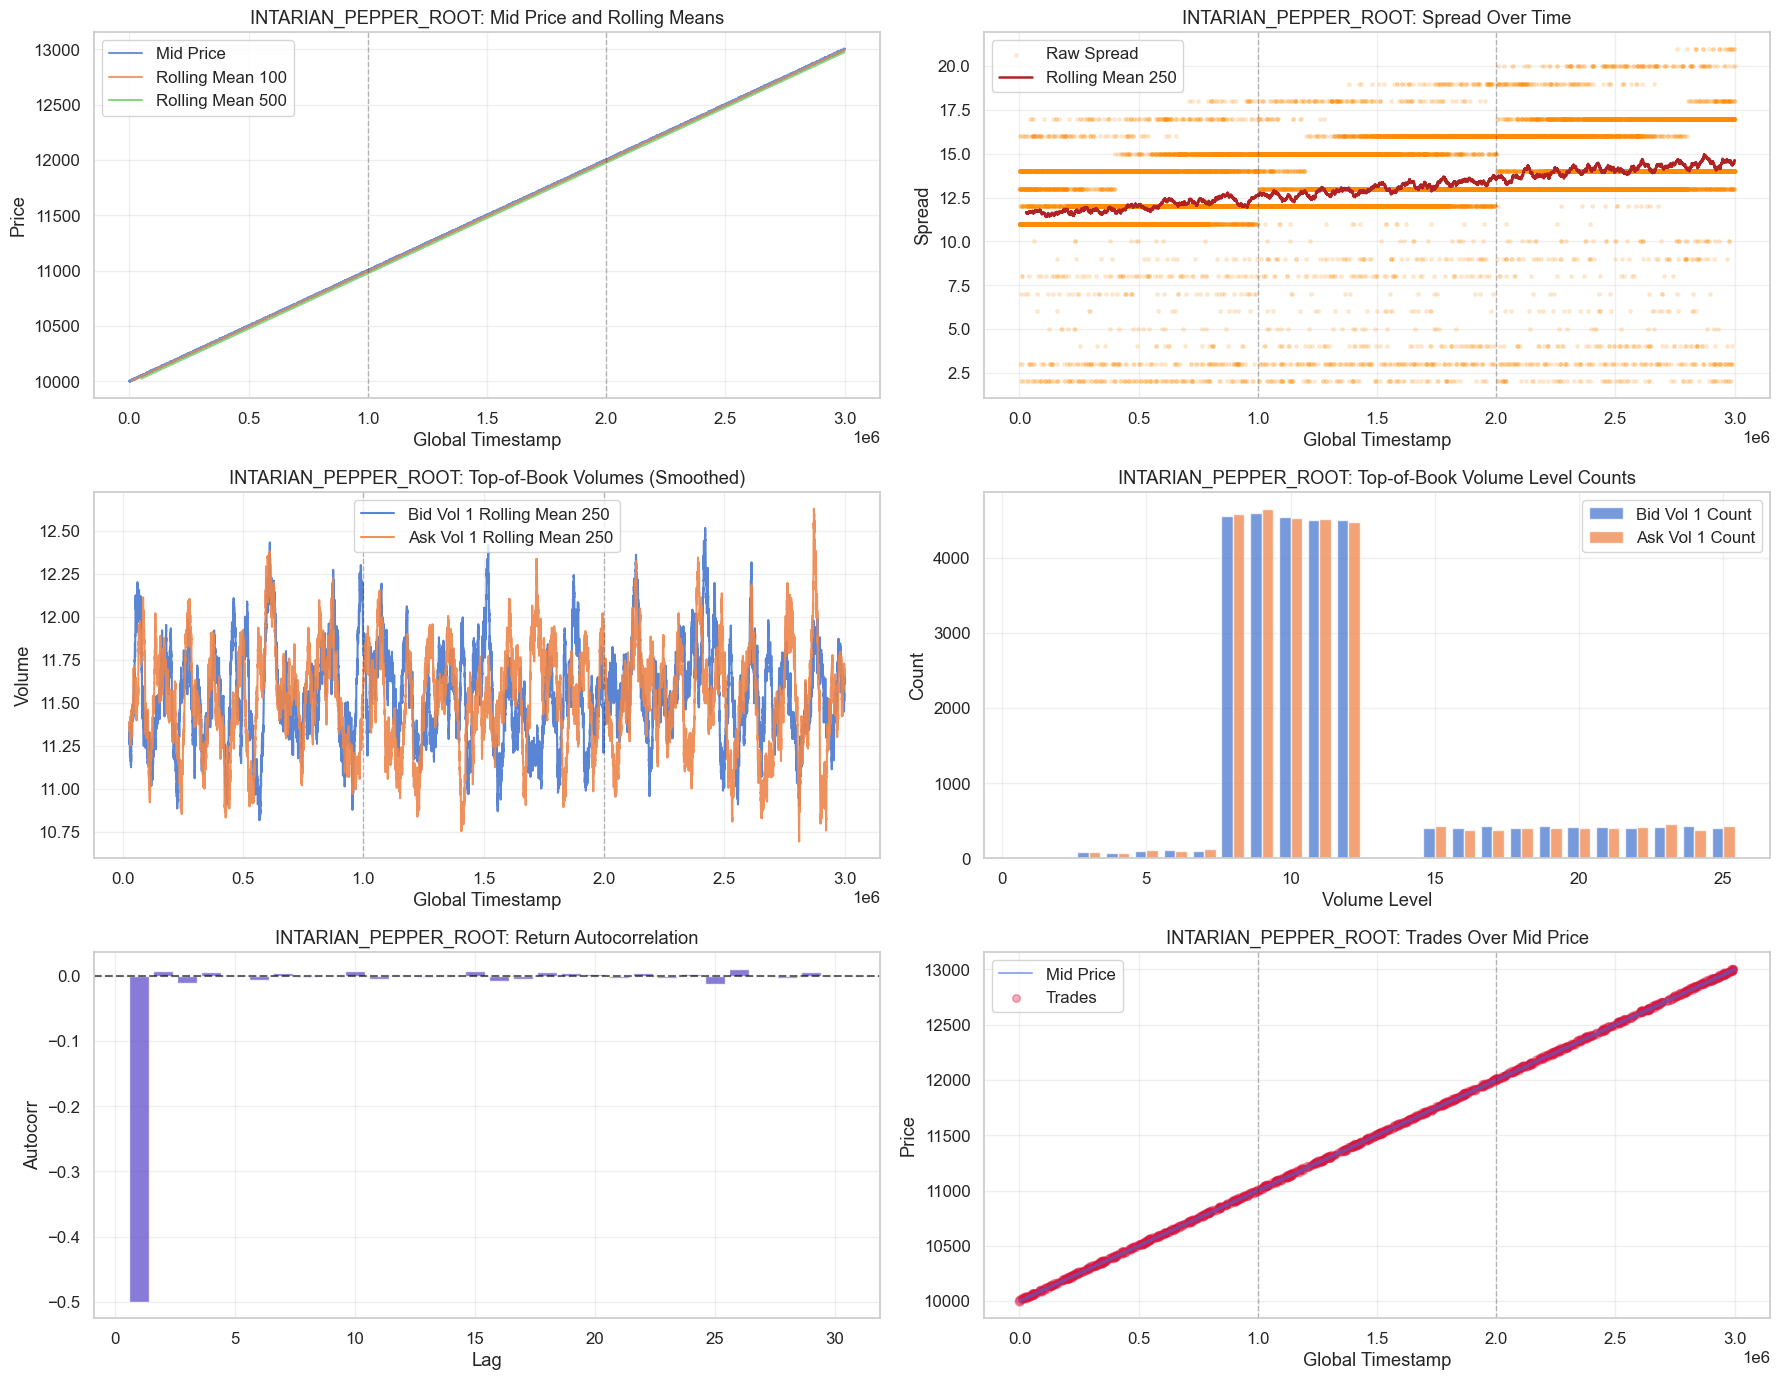

In [5]:
plot_first_pass(pepper_prices, pepper_trades, 'INTARIAN_PEPPER_ROOT', short_window=100, long_window=500, acf_lags=30)


### Pepper Root Broad-Pass Metrics

Compact tables to quantify what the broad-pass plots are showing.


In [6]:
display_broad_pass_metrics(pepper_prices, pepper_trades, 'INTARIAN_PEPPER_ROOT')


INTARIAN_PEPPER_ROOT: Day-Level Mid Summary


,start_mid,end_mid,mid_mean,mid_std
day,,,,
-2,9998.5,11001.5,10499.9635,288.7224
-1,10998.5,11998.0,11500.0301,288.6690
0,11998.5,13000.0,12500.1730,288.7310


INTARIAN_PEPPER_ROOT: Spread Summary


,mean_spread,median_spread,std_spread,p10_spread,p90_spread
0,13.0467,13.0,2.6271,11.0,16.0


INTARIAN_PEPPER_ROOT: Top-of-Book Summary


,bid_vol1_mean,bid_vol1_median,ask_vol1_mean,ask_vol1_median
0,11.5499,10.0,11.5203,10.0


INTARIAN_PEPPER_ROOT: Most Frequent Top-of-Book Volume Levels


,bid_vol_count,ask_vol_count,total_count
volume_level,,,
9.0,4598,4645,9243
8.0,4564,4584,9148
10.0,4549,4533,9082
11.0,4499,4520,9019
12.0,4506,4483,8989
23.0,412,457,869
19.0,425,406,831
15.0,403,422,825
25.0,401,422,823


INTARIAN_PEPPER_ROOT: Trade Summary


,trade_count,trade_qty_mean,trade_qty_median,trade_qty_max
0,1011,5.1731,5.0,8


## Broad Pass: ASH_COATED_OSMIUM

Questions for this first pass:
- Does Osmium look like a moving-anchor product, a trend product, or a spike-reversal product?
- Is volatility high enough to make passive quoting dangerous?
- Are trade prints clustered in a way worth testing later?


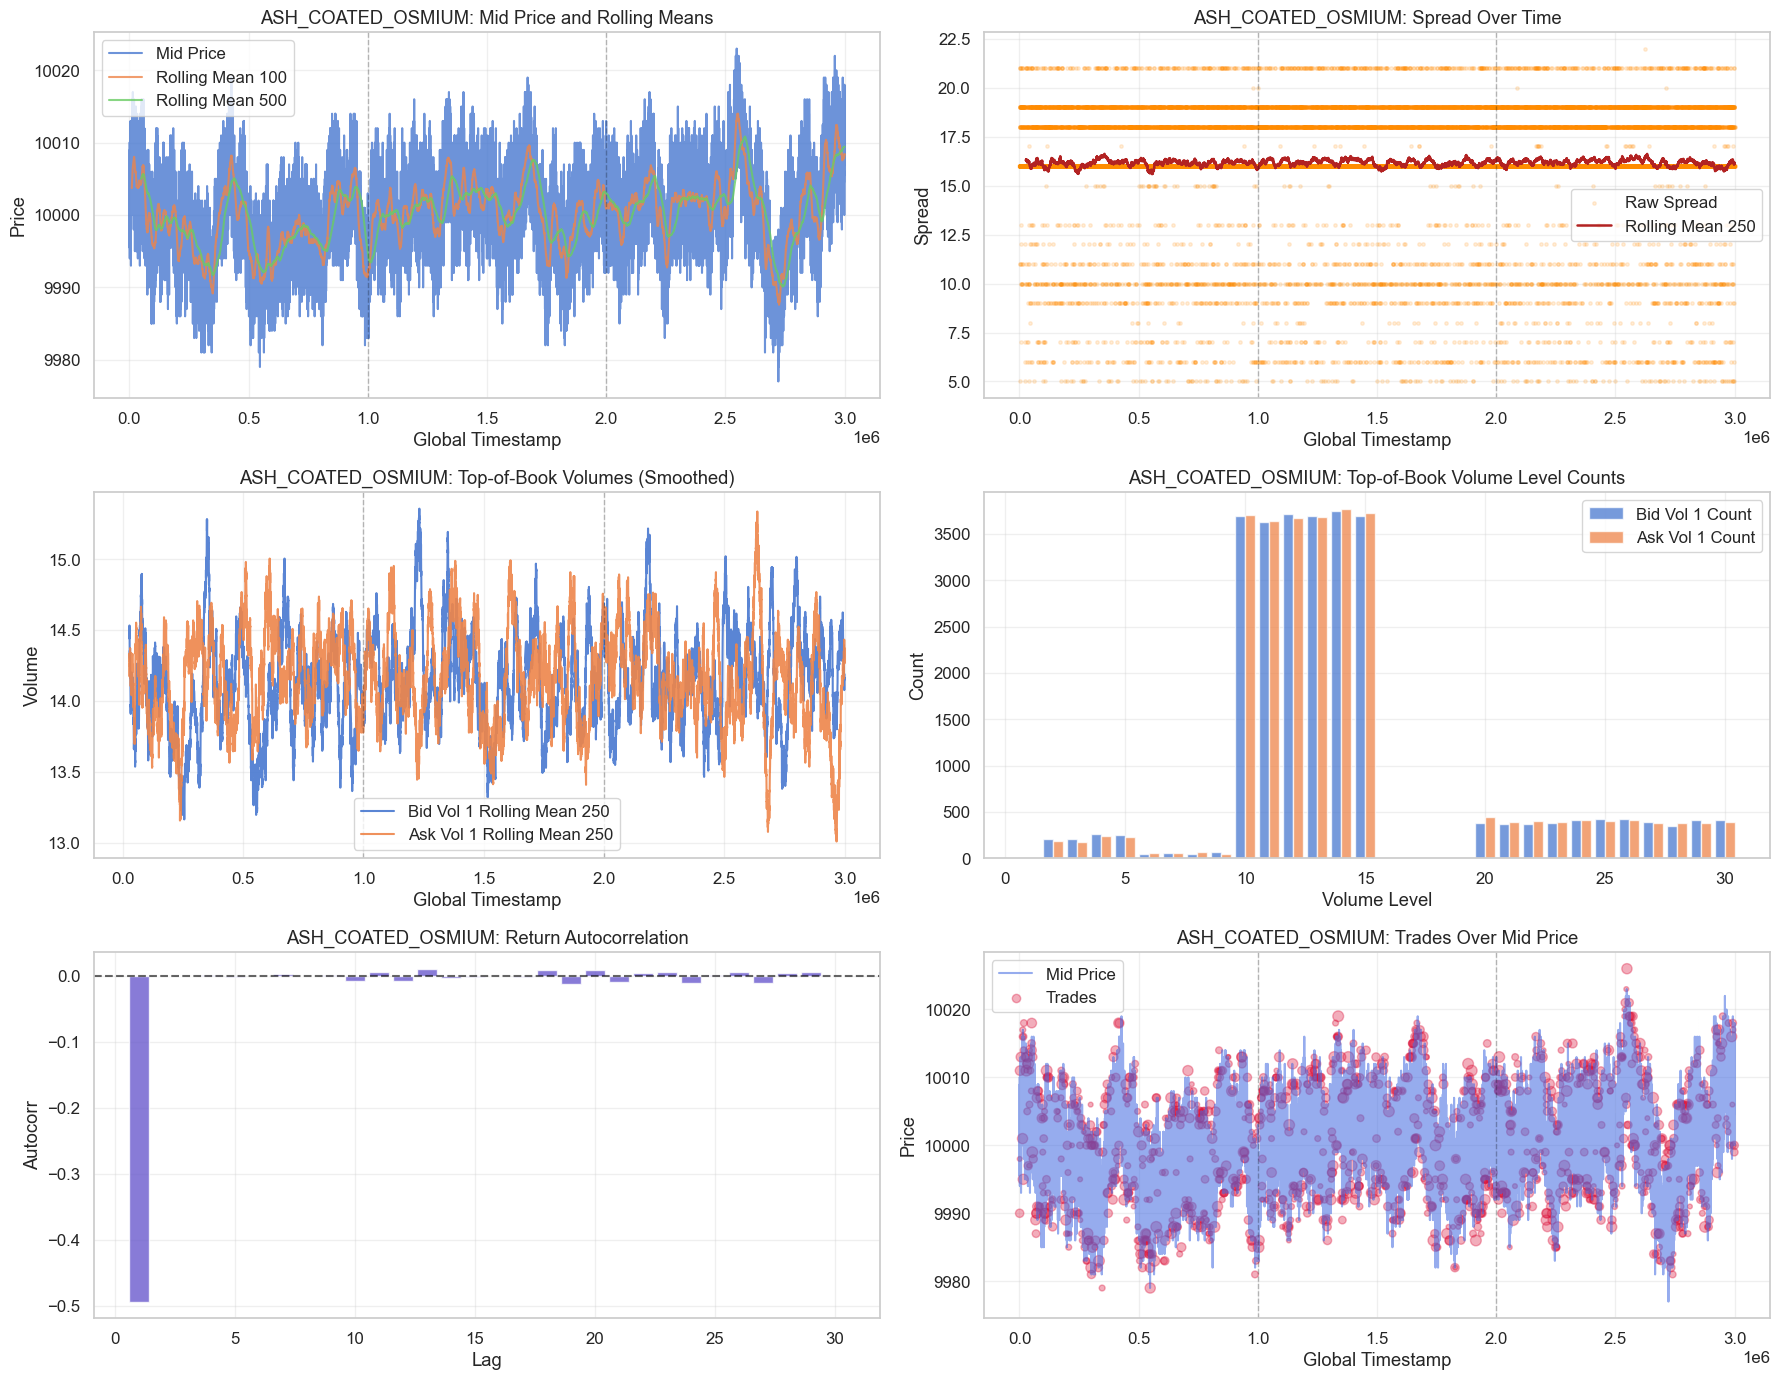

In [7]:
plot_first_pass(osmium_prices, osmium_trades, 'ASH_COATED_OSMIUM', short_window=100, long_window=500, acf_lags=30)


### Osmium Broad-Pass Metrics

Compact tables to quantify what the broad-pass plots are showing.


In [8]:
display_broad_pass_metrics(osmium_prices, osmium_trades, 'ASH_COATED_OSMIUM')


ASH_COATED_OSMIUM: Day-Level Mid Summary


,start_mid,end_mid,mid_mean,mid_std
day,,,,
-2,10010.0,9993.5,9998.1699,5.2199
-1,10003.0,10002.0,10000.8340,4.4500
0,10013.0,10007.0,10001.6082,5.6837


ASH_COATED_OSMIUM: Spread Summary


,mean_spread,median_spread,std_spread,p10_spread,p90_spread
0,16.1752,16.0,2.571,16.0,19.0


ASH_COATED_OSMIUM: Top-of-Book Summary


,bid_vol1_mean,bid_vol1_median,ask_vol1_mean,ask_vol1_median
0,14.1359,13.0,14.165,13.0


ASH_COATED_OSMIUM: Most Frequent Top-of-Book Volume Levels


,bid_vol_count,ask_vol_count,total_count
volume_level,,,
14.0,3747,3765,7512
15.0,3697,3729,7426
10.0,3699,3710,7409
12.0,3721,3673,7394
13.0,3699,3680,7379
11.0,3624,3645,7269
26.0,418,408,826
25.0,420,405,825
20.0,384,440,824


ASH_COATED_OSMIUM: Trade Summary


,trade_count,trade_qty_mean,trade_qty_median,trade_qty_max
0,1265,5.2119,5.0,10


## Pepper Root Deep Dive: Linear Trend Hypothesis

Current working hypothesis: Pepper Root is well described by a day-specific linear trend plus relatively small residual noise around that trend.

The goal here is to test that directly rather than guessing from the broad-pass plots.


In [9]:
pepper_regression_summary, pepper_reg_df = fit_linear_trend_by_day(pepper_prices)
display(pepper_regression_summary)


,day,slope_per_tick,intercept,r2,residual_mean,residual_std,residual_abs_mean,residual_lag1_autocorr
0,-2,0.001,9999.979278,0.999952,-0.0,2.009514,1.052244,0.013117
1,-1,0.001,10999.965698,0.999941,0.0,2.220585,1.160618,0.010534
2,0,0.001,11999.950821,0.999933,-0.0,2.359912,1.216139,0.002899


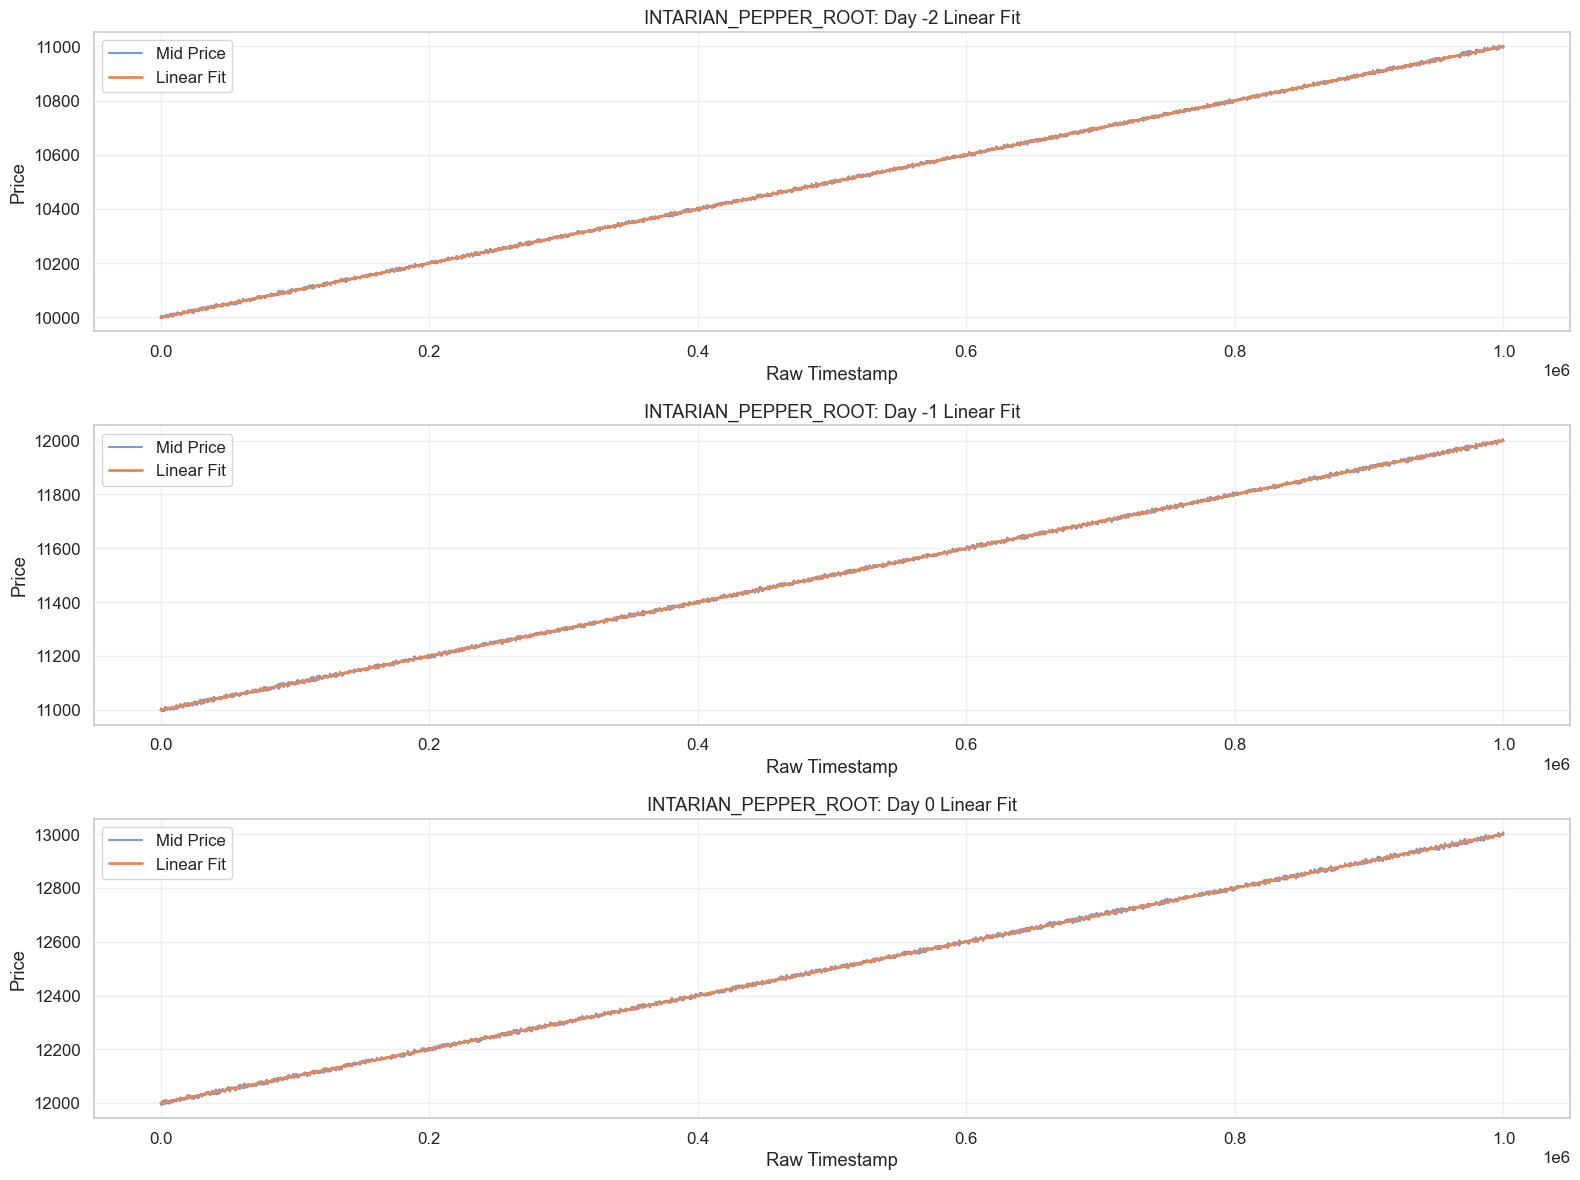

In [10]:
plot_daywise_regression(pepper_reg_df, 'INTARIAN_PEPPER_ROOT')


### Pepper Root Residual Diagnostics

If the linear-trend view is right, the residuals should be far more stationary than the raw price series and may show short-horizon mean reversion.


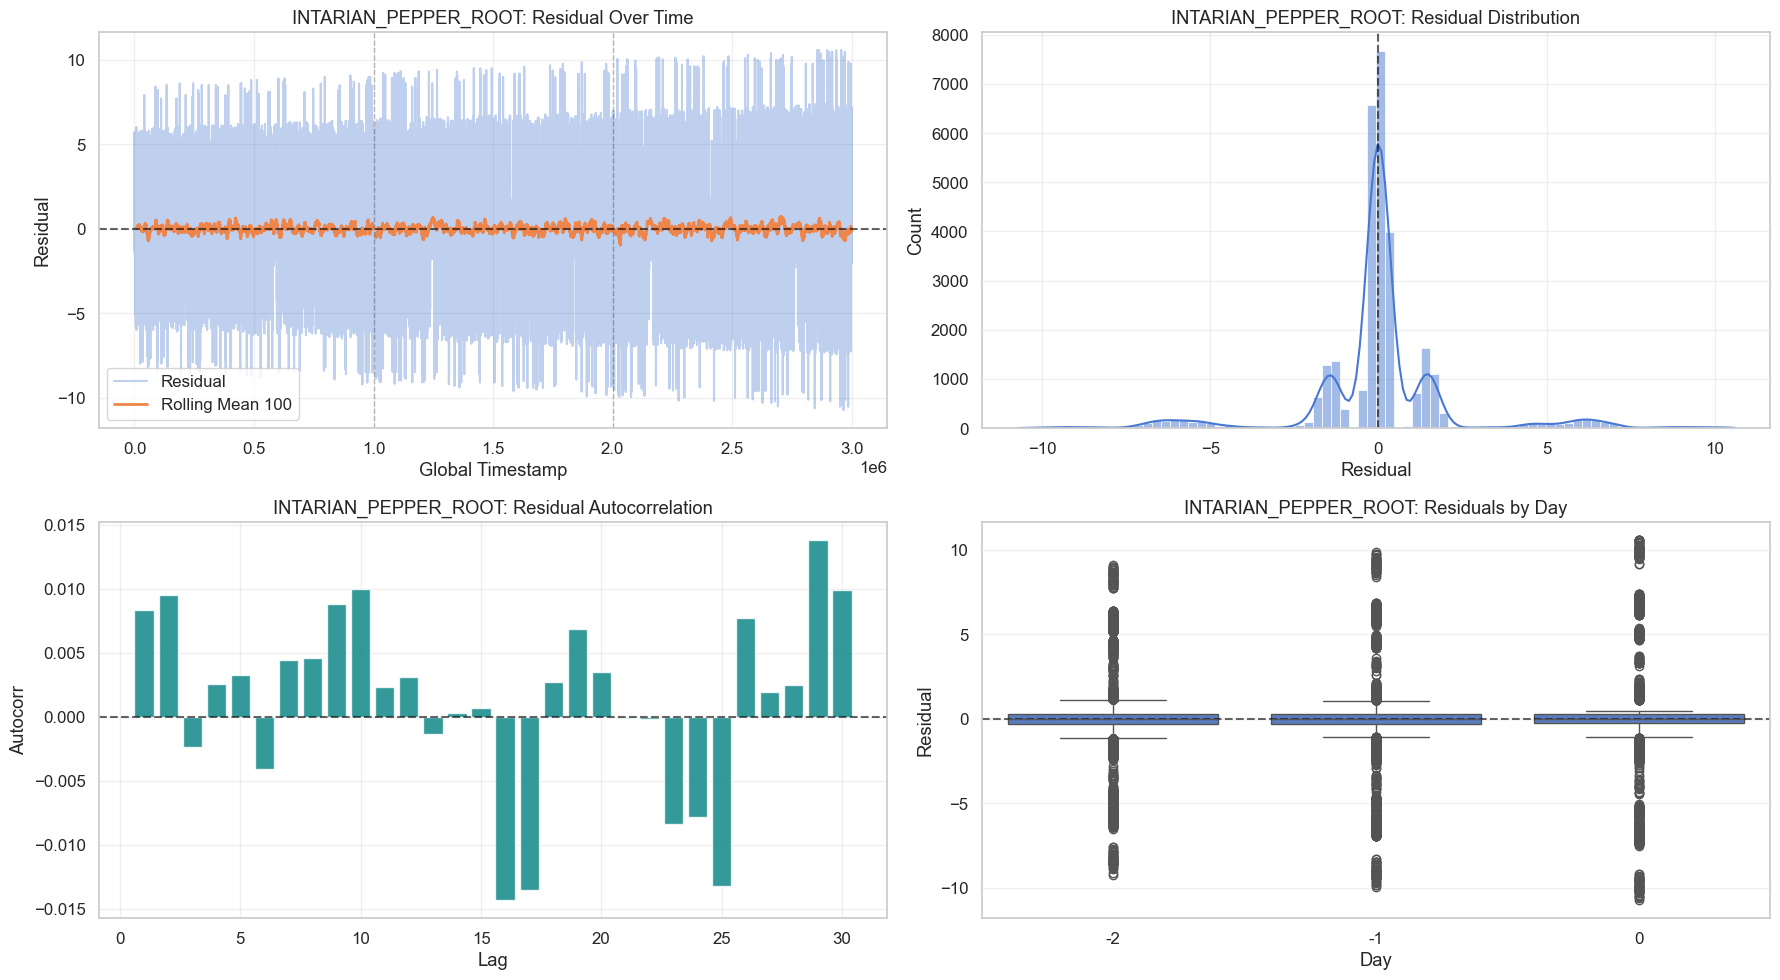

In [11]:
plot_residual_diagnostics(pepper_reg_df, 'INTARIAN_PEPPER_ROOT', residual_window=100, acf_lags=30)


In [12]:
pepper_resid_reversion = residual_reversion_table(pepper_reg_df, z_threshold=2.0, horizons=(1, 5, 10, 20))
display(pepper_resid_reversion)


,horizon,positive_extreme_count,mean_resid_change_after_pos_extreme,negative_extreme_count,mean_resid_change_after_neg_extreme
0,1,1530,-6.2993,1538,6.1577
1,5,1528,-6.1725,1537,6.2181
2,10,1528,-6.2673,1537,6.1567
3,20,1528,-6.2965,1537,6.2508


### Pepper Root Online Fair-Value Estimator Comparison

The offline daywise linear fit is useful for understanding structure, but it is not a live-trading estimator. Here we compare realistic online approximations against that trend proxy.

Estimator families tested:
- rolling mean
- EMA
- rolling linear regression


In [13]:
pepper_estimator_df = add_pepper_online_estimators(pepper_reg_df, mean_windows=(50, 100, 250), ema_spans=(50, 100, 250), reg_windows=(50, 100, 250))
pepper_estimator_cols = [
    'roll_mean_50', 'roll_mean_100', 'roll_mean_250',
    'ema_50', 'ema_100', 'ema_250',
    'roll_reg_50', 'roll_reg_100', 'roll_reg_250',
]
pepper_estimator_summary = summarize_estimator_errors(pepper_estimator_df, pepper_estimator_cols)
display(pepper_estimator_summary)


,estimator,rows_used,mae_vs_trend,rmse_vs_trend,bias_vs_trend,corr_with_trend
8,roll_reg_250,29199,0.236608,0.297627,0.002506,1.0
7,roll_reg_100,29649,0.362048,0.457539,0.001216,1.0
6,roll_reg_50,29799,0.492945,0.624683,-0.000025,1.0
3,ema_50,29946,2.451903,2.473423,-2.451903,1.0
0,roll_mean_50,29799,2.454369,2.475953,-2.454369,1.0
4,ema_100,29946,4.941361,4.949784,-4.941361,1.0
1,roll_mean_100,29649,4.958569,4.964150,-4.958569,1.0
5,ema_250,29946,12.334518,12.365032,-12.334518,1.0
2,roll_mean_250,29199,12.472035,12.472998,-12.472035,1.0


### Pepper Root Online Residual Signal Quality

Now test whether live-feasible residuals from the best online estimators still produce a useful mean-reversion signal.

We focus on the strongest candidates from the previous table: `roll_reg_100` and `roll_reg_250`.


In [14]:
pepper_signal_df = add_online_residual_signals(pepper_estimator_df, ['roll_reg_100', 'roll_reg_250'])
pepper_online_signal_table = online_residual_signal_table(pepper_signal_df, ['roll_reg_100', 'roll_reg_250'], z_threshold=2.0, horizons=(1, 5, 10, 20))
display(pepper_online_signal_table)


,estimator,horizon,positive_extreme_count,mean_mid_change_after_pos_extreme,mean_resid_change_after_pos_extreme,negative_extreme_count,mean_mid_change_after_neg_extreme,mean_resid_change_after_neg_extreme
0,roll_reg_100,1,1407,-6.3337,-6.4276,1464,6.3125,6.2125
1,roll_reg_100,5,1405,-5.7836,-6.2718,1463,6.7638,6.2490
2,roll_reg_100,10,1405,-5.4078,-6.3860,1463,7.2068,6.1826
3,roll_reg_100,20,1405,-4.3900,-6.3327,1463,8.2748,6.2186
4,roll_reg_250,1,1433,-6.2645,-6.3633,1470,6.2871,6.1876
5,roll_reg_250,5,1431,-5.7425,-6.2432,1469,6.7321,6.2293
6,roll_reg_250,10,1431,-5.3557,-6.3551,1469,7.1678,6.1646
7,roll_reg_250,20,1431,-4.3508,-6.3451,1469,8.2573,6.2450


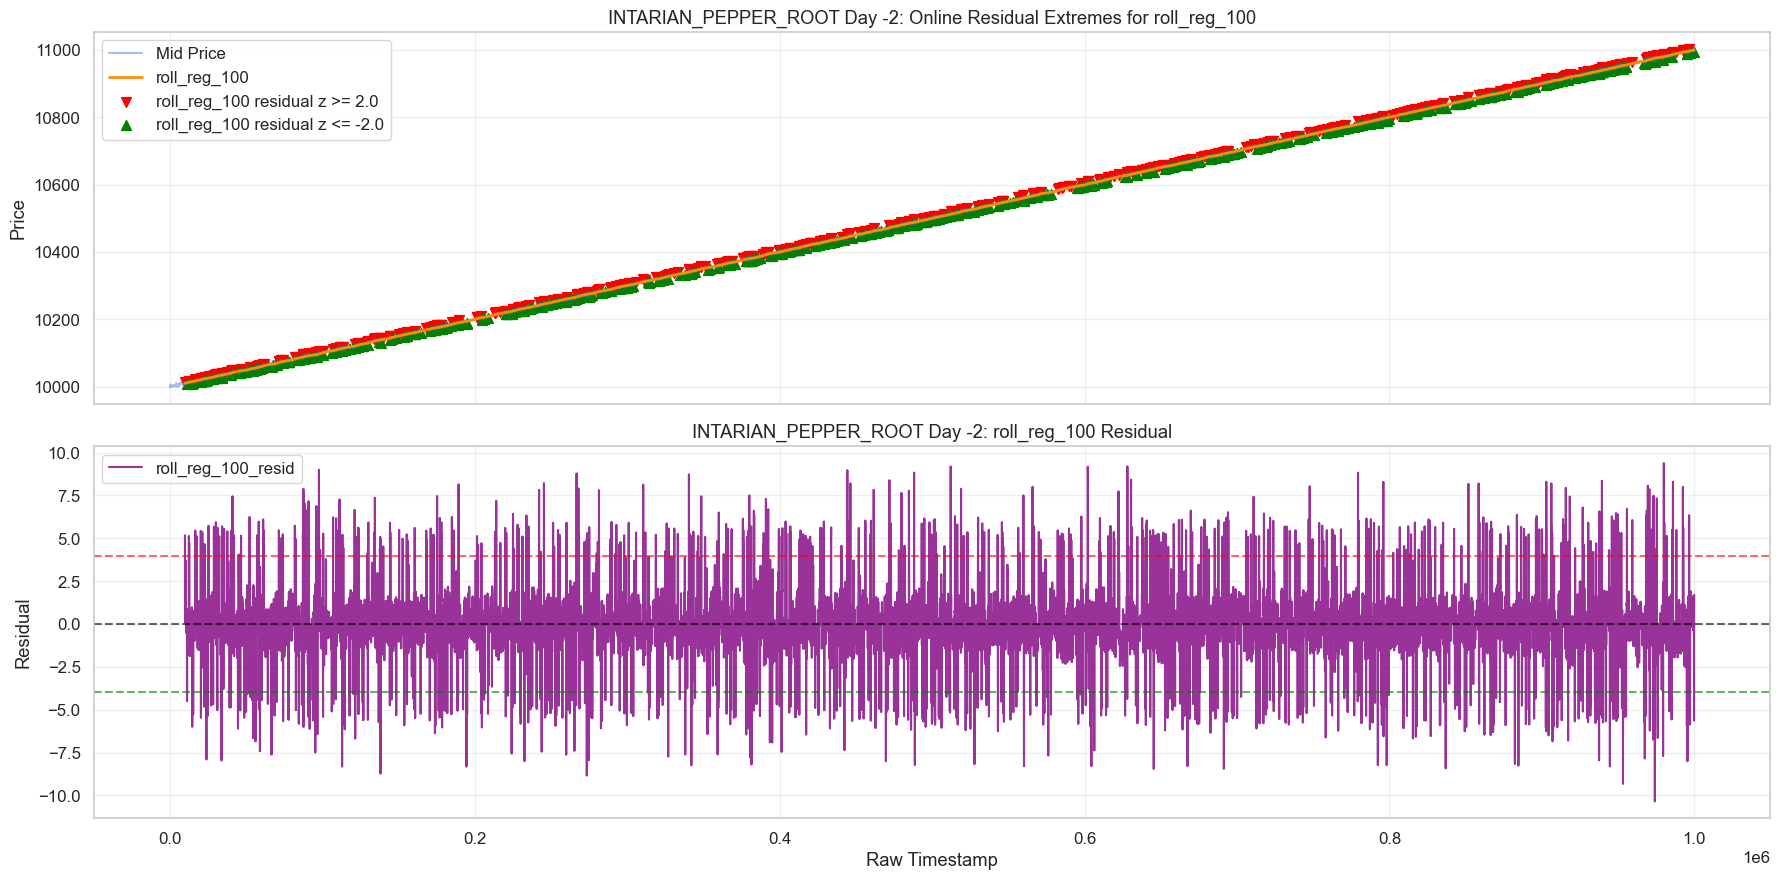

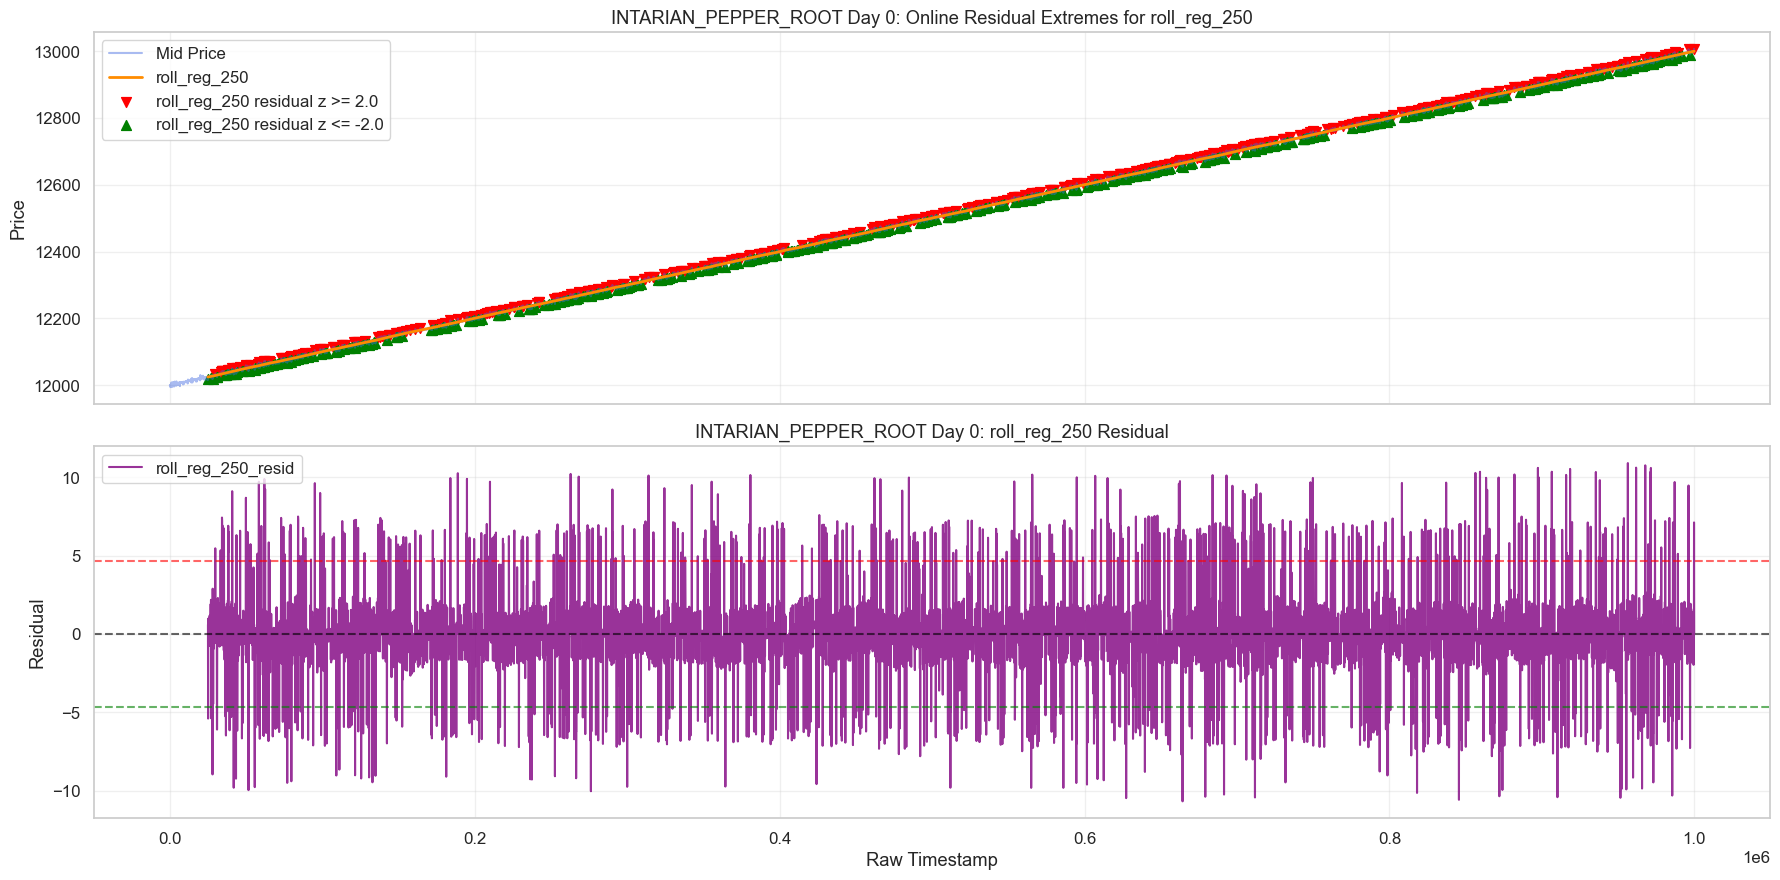

In [15]:
plot_online_residuals(pepper_signal_df, 'roll_reg_100', day=-2, z_threshold=2.0)
plot_online_residuals(pepper_signal_df, 'roll_reg_250', day=0, z_threshold=2.0)


### Pepper Root Threshold Sensitivity

Choose a practical threshold by balancing:
- event frequency
- one-step reversion strength
- symmetry between positive and negative signals

We keep this intentionally narrow to avoid turning the notebook into a parameter search exercise.


In [16]:
pepper_threshold_roll_reg_100 = threshold_sensitivity_table(pepper_signal_df, 'roll_reg_100', thresholds=(1.0, 1.5, 2.0, 2.5, 3.0), horizon=1)
pepper_threshold_roll_reg_250 = threshold_sensitivity_table(pepper_signal_df, 'roll_reg_250', thresholds=(1.0, 1.5, 2.0, 2.5, 3.0), horizon=1)
display(pepper_threshold_roll_reg_100)
display(pepper_threshold_roll_reg_250)


,estimator,threshold,pos_events,mean_mid_change_after_pos_extreme,mean_resid_change_after_pos_extreme,neg_events,mean_mid_change_after_neg_extreme,mean_resid_change_after_neg_extreme
0,roll_reg_100,1.0,1848,-5.4913,-5.5875,1889,5.4778,5.3795
1,roll_reg_100,1.5,1592,-6.0810,-6.1750,1558,6.1788,6.0790
2,roll_reg_100,2.0,1407,-6.3337,-6.4276,1464,6.3125,6.2125
3,roll_reg_100,2.5,1063,-6.7079,-6.8028,1051,6.7407,6.6403
4,roll_reg_100,3.0,373,-7.9115,-8.0050,358,7.6369,7.5453


,estimator,threshold,pos_events,mean_mid_change_after_pos_extreme,mean_resid_change_after_pos_extreme,neg_events,mean_mid_change_after_neg_extreme,mean_resid_change_after_neg_extreme
0,roll_reg_250,1.0,1682,-5.8092,-5.9085,1712,5.7681,5.6691
1,roll_reg_250,1.5,1571,-6.0726,-6.1716,1531,6.1845,6.0851
2,roll_reg_250,2.0,1433,-6.2645,-6.3633,1470,6.2871,6.1876
3,roll_reg_250,2.5,1124,-6.6570,-6.7563,1079,6.7475,6.6479
4,roll_reg_250,3.0,358,-7.9218,-8.0214,344,7.8169,7.7181


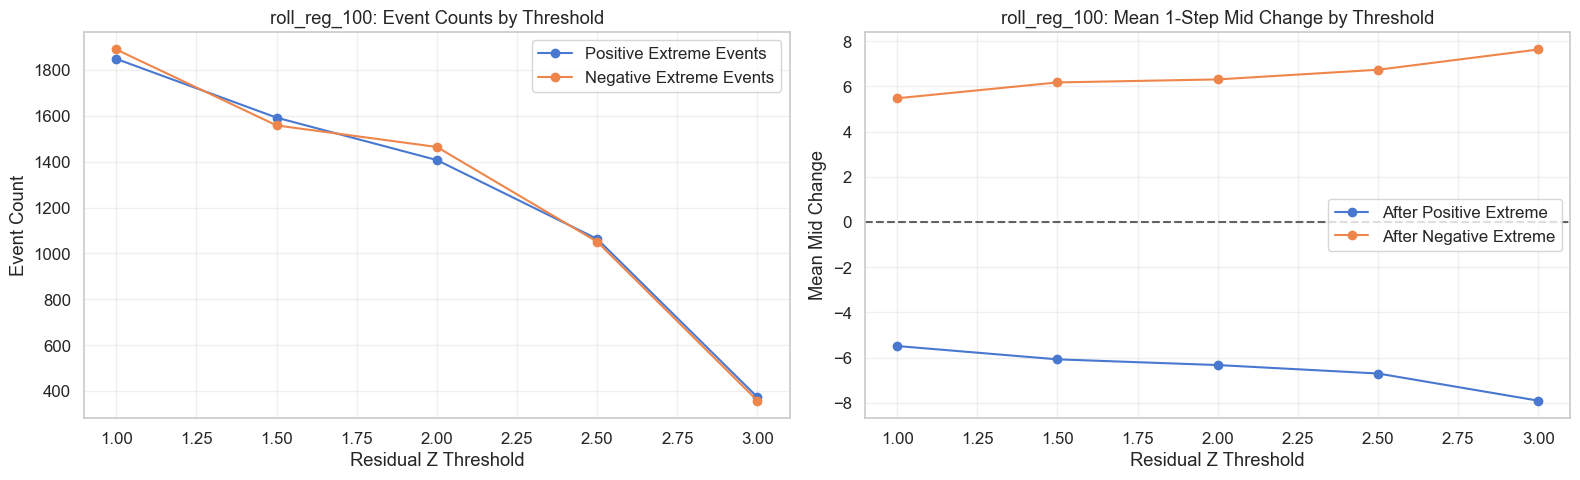

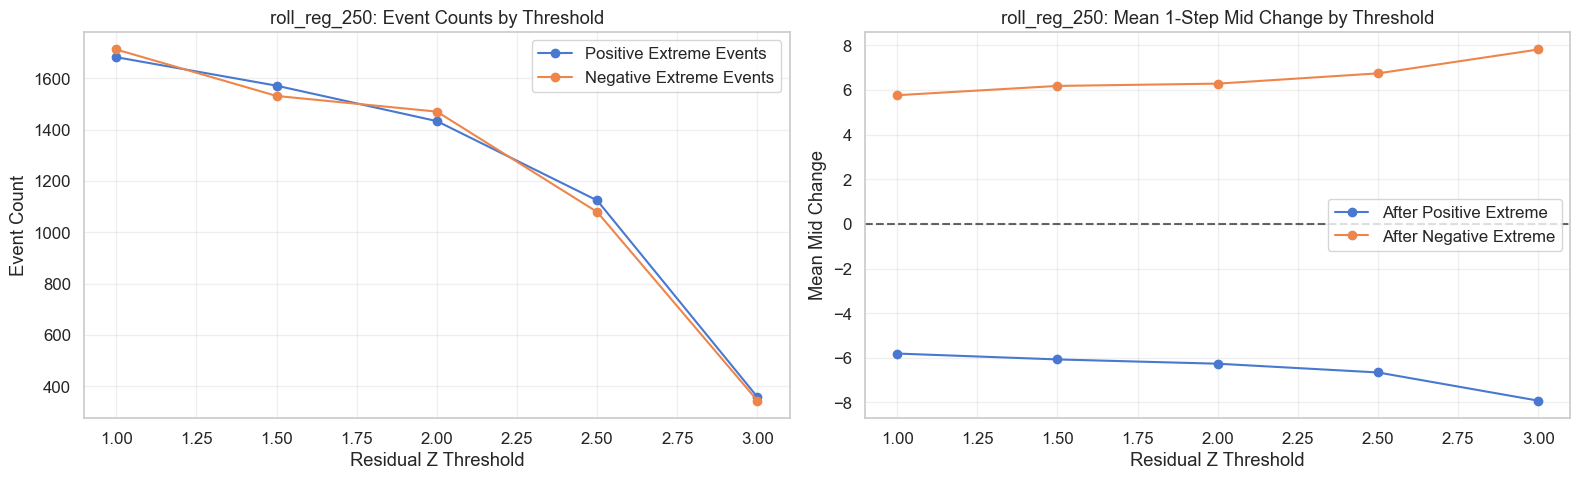

In [17]:
plot_threshold_event_counts(pepper_threshold_roll_reg_100, 'roll_reg_100')
plot_threshold_event_counts(pepper_threshold_roll_reg_250, 'roll_reg_250')


## Key Findings So Far

### Broad Round 1 Classification
- `INTARIAN_PEPPER_ROOT` is not a fixed-fair-value product. It follows a very strong day-specific linear trend with small residual noise around that trend.
- `ASH_COATED_OSMIUM` is much closer to a stationary product around `10000`, though it is visually noisier than Pepper Root in the raw mid-price plot.
- Both products show strong short-horizon negative lag-1 behavior, but that alone does not determine the right fair-value model.

### Pepper Root
- A day-specific linear fit explains the price path almost perfectly (`R^2` extremely close to 1 by day).
- Residuals around the linear fit are small and stable.
- Large residual deviations mean revert strongly and quickly.
- Causal rolling-regression fair values preserve this edge almost as well as the offline daywise fit.
- The best online fair-value family is rolling regression, with `roll_reg_100` and `roll_reg_250` both working well.
- A practical first trigger range looks to be around residual `z = 1.5` to `2.0`.

### Implication For Next Steps
- Pepper Root is now well understood enough to support a first trader design hypothesis.
- The next product to analyze is Osmium, with the main question being whether a constant fair value is sufficient or whether filtered order-book fair values materially improve the signal.


## Osmium Deep Dive

Current working hypothesis: Osmium is the more stationary Round 1 product, likely centered near `10000`. The main open question is whether a simple constant fair value is enough, or whether filtered order-book fair values such as wall-mid improve the signal enough to justify added complexity.


In [18]:
osmium_deep_df = add_wall_mid_features(osmium_prices, volume_thresholds=(10, 15, 20))
osmium_deep_df['constant_10000'] = 10000
osmium_fair_value_summary = summarize_osmium_fair_values(osmium_deep_df, ['constant_10000', 'wall_mid_10', 'wall_mid_15', 'wall_mid_20'])
display(osmium_fair_value_summary)


,fair_value,coverage,mae_fv_to_10000,rmse_fv_to_10000,bias_fv_to_10000,mae_mid_to_fv,resid_std_mid_minus_fv
0,constant_10000,1.000000,0.000000,0.000000,0.000000,4.197489,5.349695
3,wall_mid_20,0.633702,3.751923,4.699524,0.229004,0.967914,1.390652
2,wall_mid_15,0.681713,3.762930,4.716052,0.232956,0.821236,1.339259
1,wall_mid_10,0.919201,3.768261,4.749133,0.222404,0.287712,1.087583


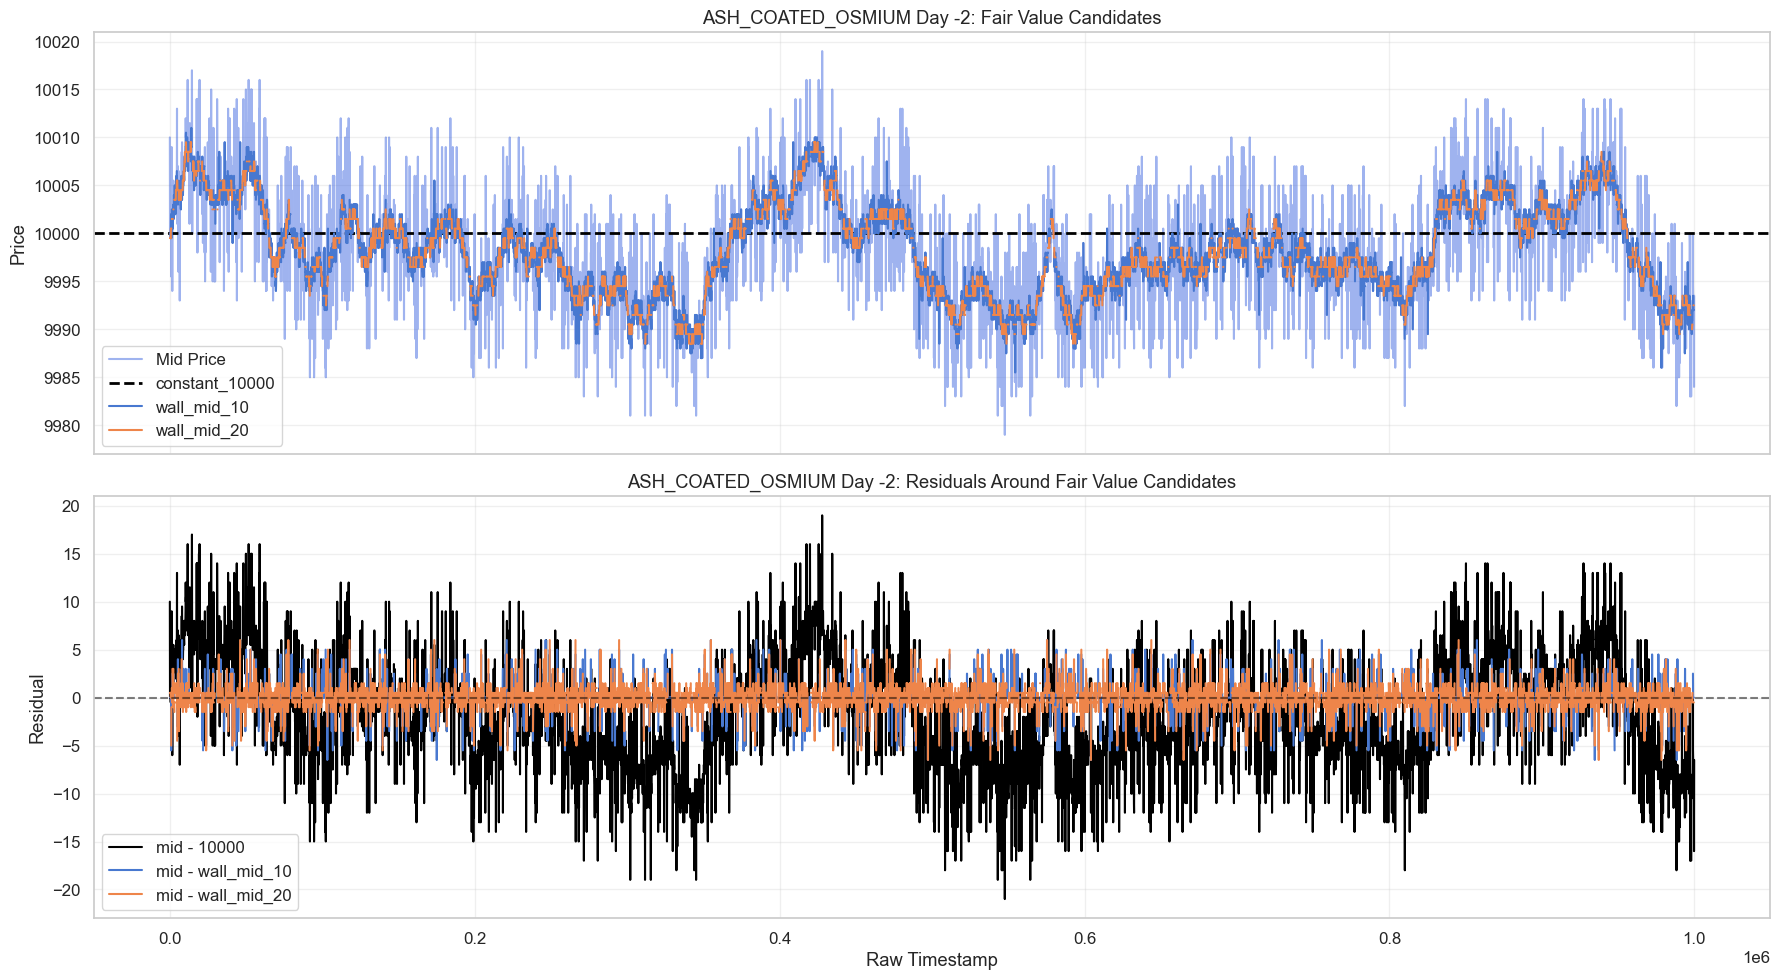

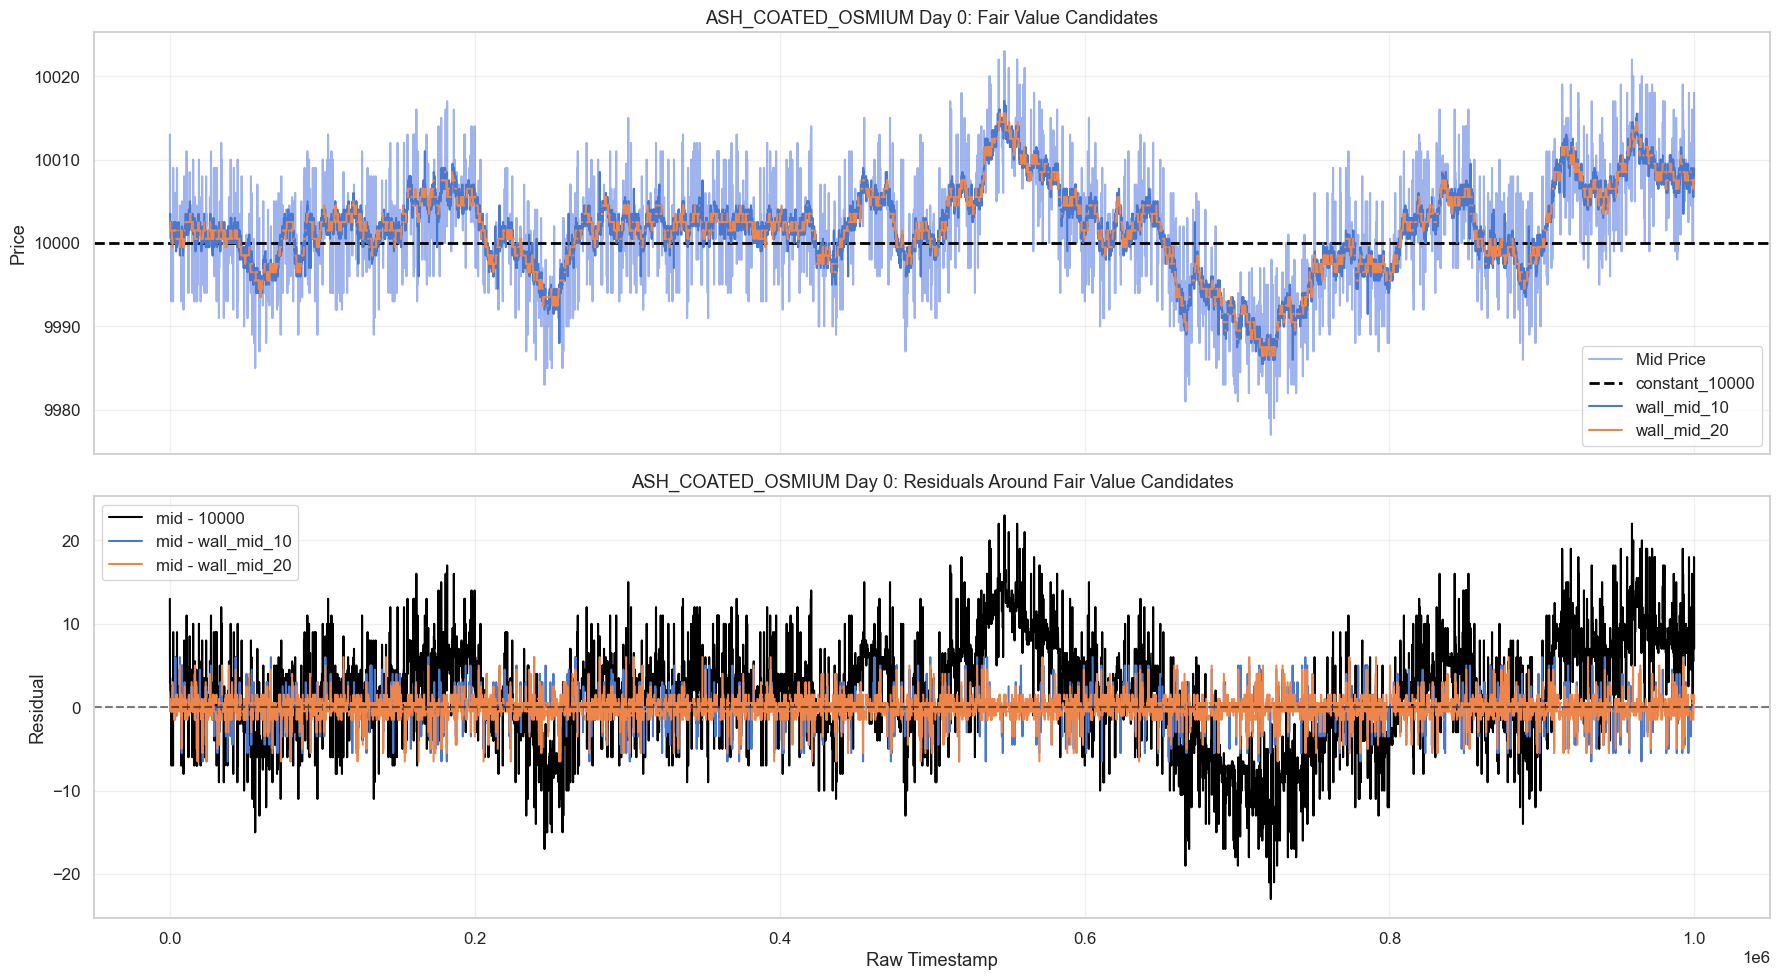

In [19]:
plot_osmium_fair_value_comparison(osmium_deep_df, ['wall_mid_10', 'wall_mid_20'], day=-2)
plot_osmium_fair_value_comparison(osmium_deep_df, ['wall_mid_10', 'wall_mid_20'], day=0)


### Osmium Signal Quality Around Candidate Fair Values

This tests whether extreme deviations from each fair-value candidate tend to revert over the next timestep. The aim is not to optimize a final threshold yet, but to determine whether simple constant fair value is already strong enough or if filtered wall-mid materially improves the setup.


In [20]:
osmium_signal_table = osmium_signal_quality(
    osmium_deep_df,
    [('constant_10000', 'constant_10000'), ('wall_mid_10', 'wall_mid_10'), ('wall_mid_20', 'wall_mid_20')],
    thresholds=(1.0, 1.5, 2.0, 2.5),
    horizon=1,
)
display(osmium_signal_table)


,fair_value,threshold,pos_events,mean_mid_change_after_pos_extreme,neg_events,mean_mid_change_after_neg_extreme
0,constant_10000,1.0,4888,-1.9826,4665,1.9502
1,constant_10000,1.5,2320,-3.0041,2296,2.7376
2,constant_10000,2.0,926,-4.6188,825,4.8630
3,constant_10000,2.5,259,-6.7741,220,7.6114
4,wall_mid_10,1.0,1072,-3.7817,1012,4.0593
5,wall_mid_10,1.5,1072,-3.7817,1012,4.0593
6,wall_mid_10,2.0,1072,-3.7817,1012,4.0593
7,wall_mid_10,2.5,735,-4.1014,1012,4.0593
8,wall_mid_20,1.0,2128,-2.2279,2145,2.1692
9,wall_mid_20,1.5,759,-3.8241,747,4.1700


### Osmium Residual Structure and Quote Geometry

The filtered wall-mid fit is strong, but the residuals are highly discrete. That means the next question is not just whether Osmium mean reverts, but whether its book lives in a stable geometry around a filtered fair value and whether raw residual levels are more informative than standardized z-scores.


In [21]:

def summarize_residual_levels(df: pd.DataFrame, fair_value_cols: list[str], top_n: int = 8) -> pd.DataFrame:
    rows = []
    for fair_value_col in fair_value_cols:
        sub = df[df[fair_value_col].notna() & df['is_valid_mid']].copy()
        residual = (sub['mid_price'] - sub[fair_value_col]).round(4)
        vc = residual.value_counts().head(top_n)
        for level, count in vc.items():
            rows.append({
                'fair_value': fair_value_col,
                'residual_level': level,
                'count': int(count),
                'share': count / len(sub),
            })
    return pd.DataFrame(rows)


def summarize_quote_geometry(df: pd.DataFrame, fair_value_col: str) -> pd.DataFrame:
    sub = df[df[fair_value_col].notna() & df['is_two_sided']].copy()
    sub['bid_dist'] = sub['bid_price_1'] - sub[fair_value_col]
    sub['ask_dist'] = sub['ask_price_1'] - sub[fair_value_col]
    sub['spread'] = sub['ask_price_1'] - sub['bid_price_1']
    summary = sub.groupby('day').agg(
        rows=('timestamp', 'size'),
        bid_dist_mean=('bid_dist', 'mean'),
        bid_dist_std=('bid_dist', 'std'),
        ask_dist_mean=('ask_dist', 'mean'),
        ask_dist_std=('ask_dist', 'std'),
        spread_mean=('spread', 'mean'),
        spread_std=('spread', 'std'),
    ).reset_index()
    return summary.round(4)


def raw_residual_reversion_table(
    df: pd.DataFrame,
    fair_value_col: str,
    thresholds=(0.5, 1.0, 2.0, 3.0),
    horizons=(1, 5, 10),
) -> pd.DataFrame:
    sub = df[df[fair_value_col].notna() & df['is_valid_mid']].copy()
    sub['residual_raw'] = sub['mid_price'] - sub[fair_value_col]
    rows = []
    for threshold in thresholds:
        pos = sub[sub['residual_raw'] >= threshold]
        neg = sub[sub['residual_raw'] <= -threshold]
        row = {
            'fair_value': fair_value_col,
            'threshold_raw': threshold,
            'pos_events': len(pos),
            'neg_events': len(neg),
        }
        for horizon in horizons:
            fwd = sub['mid_price'].shift(-horizon) - sub['mid_price']
            row[f'pos_mean_fwd_{horizon}'] = fwd.loc[pos.index].dropna().mean()
            row[f'neg_mean_fwd_{horizon}'] = fwd.loc[neg.index].dropna().mean()
        rows.append(row)
    return pd.DataFrame(rows).round(4)


def plot_osmium_discrete_structure(df: pd.DataFrame, fair_value_col: str, top_n: int = 10):
    sub = df[df[fair_value_col].notna() & df['is_two_sided'] & df['is_valid_mid']].copy()
    sub['residual_raw'] = (sub['mid_price'] - sub[fair_value_col]).round(4)
    sub['bid_dist'] = (sub['bid_price_1'] - sub[fair_value_col]).round(4)
    sub['ask_dist'] = (sub['ask_price_1'] - sub[fair_value_col]).round(4)
    sub['spread'] = (sub['ask_price_1'] - sub['bid_price_1']).round(4)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    value_specs = [
        ('residual_raw', 'Mid - Fair Value'),
        ('bid_dist', 'Best Bid - Fair Value'),
        ('ask_dist', 'Best Ask - Fair Value'),
        ('spread', 'Spread'),
    ]
    for ax, (col, title) in zip(axes.flatten(), value_specs):
        vc = sub[col].value_counts().head(top_n).sort_index()
        ax.bar(vc.index.astype(str), vc.values, color='steelblue', alpha=0.85)
        ax.set_title(f'{title} Most Common Levels ({fair_value_col})')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()


In [22]:

osmium_residual_levels = summarize_residual_levels(osmium_deep_df, ['wall_mid_10', 'wall_mid_20'], top_n=10)
display(osmium_residual_levels)

osmium_geometry_wall_mid_10 = summarize_quote_geometry(osmium_deep_df, 'wall_mid_10')
osmium_geometry_wall_mid_20 = summarize_quote_geometry(osmium_deep_df, 'wall_mid_20')
display(osmium_geometry_wall_mid_10)
display(osmium_geometry_wall_mid_20)

osmium_raw_reversion = raw_residual_reversion_table(
    osmium_deep_df,
    'wall_mid_10',
    thresholds=(0.5, 1.0, 1.5, 2.0, 2.5, 3.0),
    horizons=(1, 5, 10),
)
display(osmium_raw_reversion)


,fair_value,residual_level,count,share
0,wall_mid_10,0.0,25447,0.924304
1,wall_mid_10,2.5,337,0.012241
2,wall_mid_10,3.0,309,0.011224
3,wall_mid_10,-3.0,283,0.010279
4,wall_mid_10,-3.5,273,0.009916
5,wall_mid_10,-5.5,140,0.005085
6,wall_mid_10,-4.5,139,0.005049
7,wall_mid_10,4.5,132,0.004795
8,wall_mid_10,5.0,132,0.004795
9,wall_mid_10,-5.0,130,0.004722


,day,rows,bid_dist_mean,bid_dist_std,ask_dist_mean,ask_dist_std,spread_mean,spread_std
0,-2,9150,-8.0931,1.5856,8.0841,1.6891,16.1772,2.5033
1,-1,9183,-8.1288,1.5784,8.0931,1.7439,16.2218,2.5164
2,0,9198,-8.1260,1.6054,8.0858,1.8030,16.2118,2.5812


,day,rows,bid_dist_mean,bid_dist_std,ask_dist_mean,ask_dist_std,spread_mean,spread_std
0,-2,6267,-8.1523,1.7758,8.2075,1.9039,16.3598,2.5092
1,-1,6346,-8.2124,1.8432,8.1633,1.9763,16.3757,2.6058
2,0,6367,-8.2348,1.8076,8.1302,2.0823,16.3650,2.6635


,fair_value,threshold_raw,pos_events,neg_events,pos_mean_fwd_1,neg_mean_fwd_1,pos_mean_fwd_5,neg_mean_fwd_5,pos_mean_fwd_10,neg_mean_fwd_10
0,wall_mid_10,0.5,1072,1012,-3.6367,4.0973,-3.5210,4.0316,-3.5261,4.1635
1,wall_mid_10,1.0,1072,1012,-3.6367,4.0973,-3.5210,4.0316,-3.5261,4.1635
2,wall_mid_10,1.5,1072,1012,-3.6367,4.0973,-3.5210,4.0316,-3.5261,4.1635
3,wall_mid_10,2.0,1072,1012,-3.6367,4.0973,-3.5210,4.0316,-3.5261,4.1635
4,wall_mid_10,2.5,1072,1012,-3.6367,4.0973,-3.5210,4.0316,-3.5261,4.1635
5,wall_mid_10,3.0,735,1012,-3.9469,4.0973,-3.7619,4.0316,-3.8238,4.1635


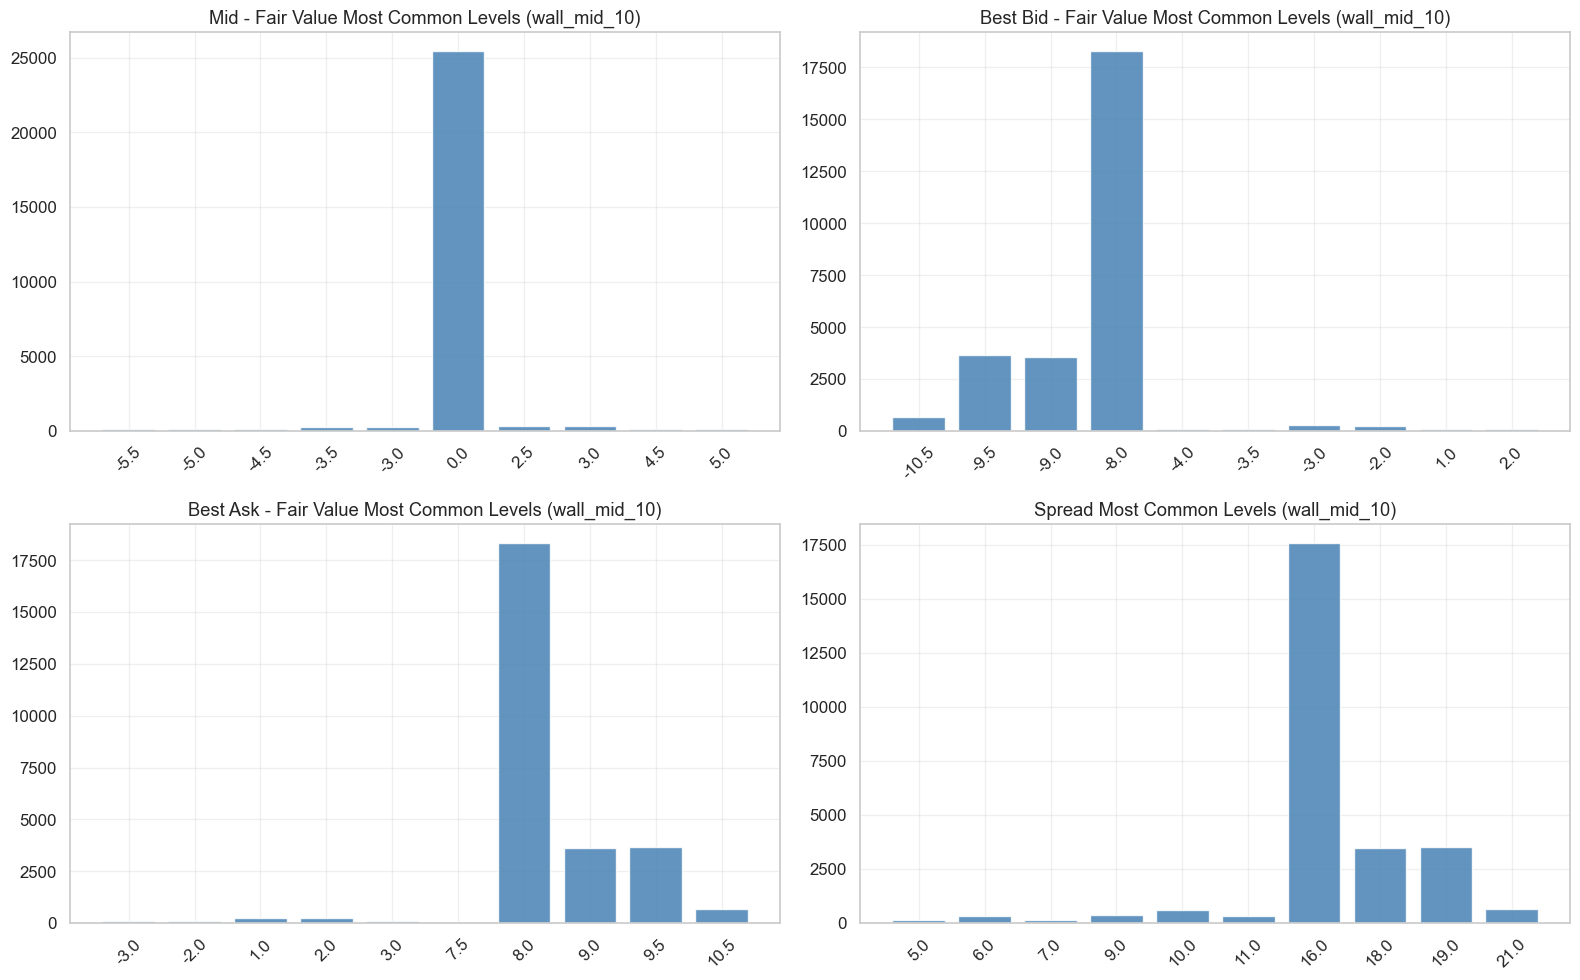

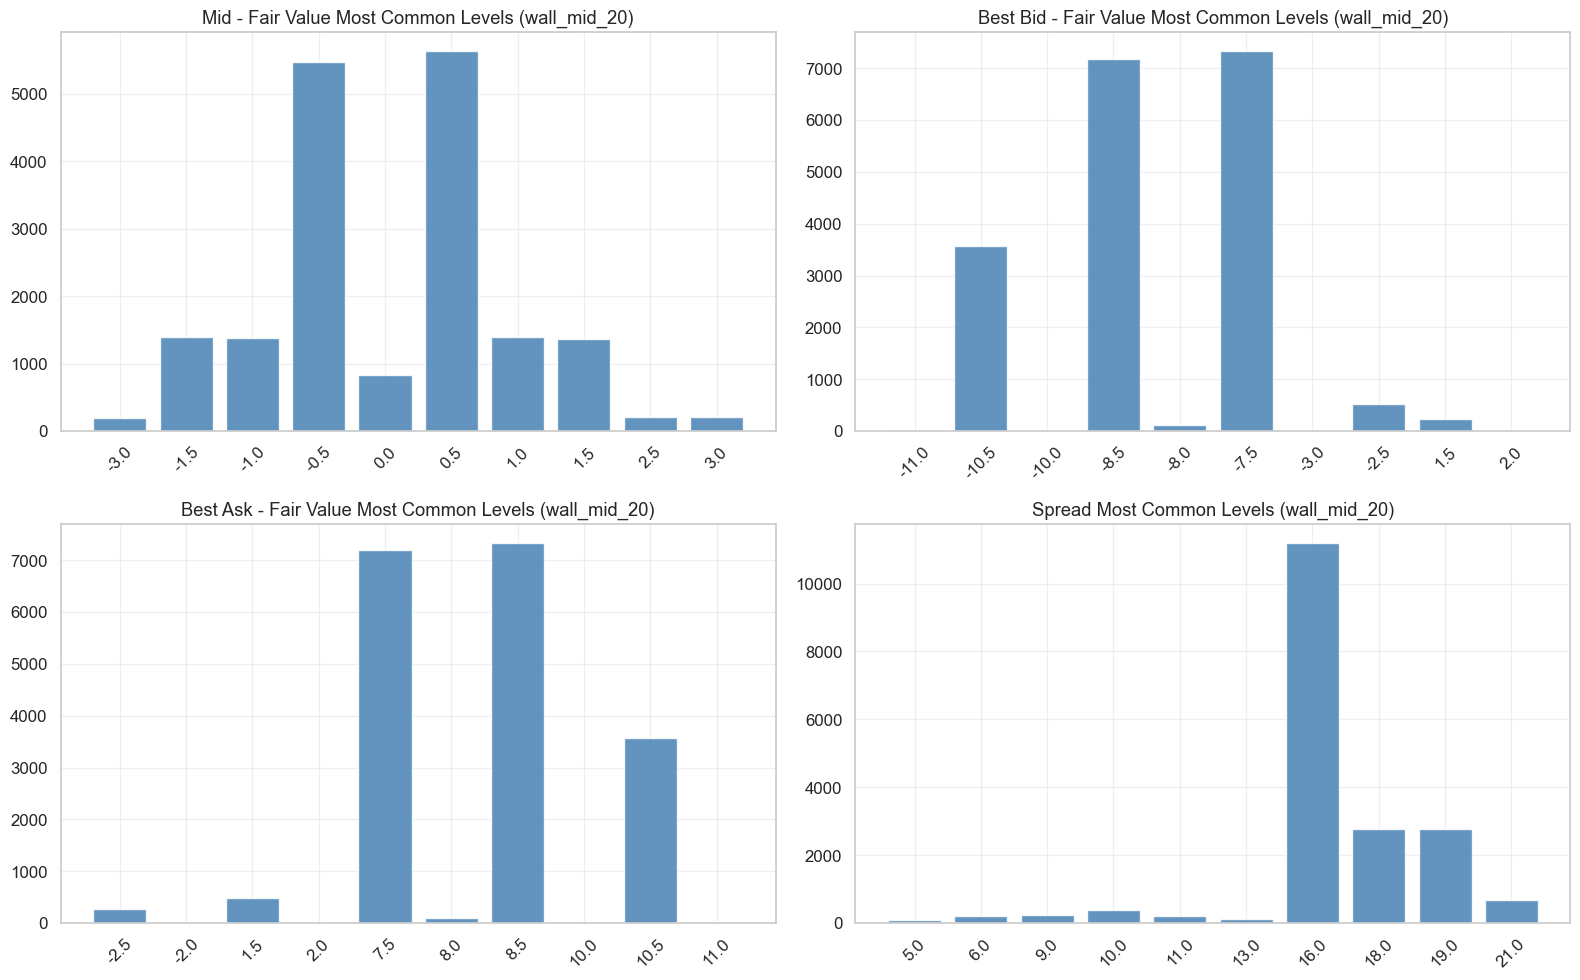

In [23]:

plot_osmium_discrete_structure(osmium_deep_df, 'wall_mid_10', top_n=10)
plot_osmium_discrete_structure(osmium_deep_df, 'wall_mid_20', top_n=10)


### Working Read on Osmium | Iteration 1

- `wall_mid_10` remains the strongest descriptive fair-value candidate by a large margin on MAE and residual variance.
- The residual distribution around `wall_mid_10` is not smooth. It is heavily concentrated at a few exact levels, especially `0.0`, which means z-score thresholds collapse to the same event set over wide ranges.
- Best bid and ask also live at a very stable distance from `wall_mid_10`, roughly `-8` and `+8` respectively, with the most common spread around `16`.
- That geometry is consistent across all three days, which points toward a stable quoting structure rather than a drifting predictive process.
- The current leading hypothesis is therefore: Osmium should probably be traded off a filtered wall-mid anchor with book-aware execution rules, and any directional signal should use raw residual levels rather than continuous standardization.


### Osmium Aggressive-Take Diagnostics

If Osmium normally lives with best quotes around roughly `wall_mid_10 ± 8`, then aggressive taking should only be interesting when the book collapses materially inside that envelope. This section measures the realized forward move after buying a best ask or selling a best bid at different edge levels relative to `wall_mid_10`.


In [24]:

def summarize_osmium_take_opportunities(
    df: pd.DataFrame,
    fair_value_col: str,
    thresholds=(-8, -6, -4, -2, 0, 2),
    horizons=(1, 5, 10),
) -> pd.DataFrame:
    sub = df[df[fair_value_col].notna() & df['is_two_sided'] & df['is_valid_mid']].copy()
    sub['buy_edge'] = sub[fair_value_col] - sub['ask_price_1']
    sub['sell_edge'] = sub['bid_price_1'] - sub[fair_value_col]
    rows = []
    for side, edge_col, sign in [('buy', 'buy_edge', 1), ('sell', 'sell_edge', -1)]:
        for threshold in thresholds:
            row = {
                'fair_value': fair_value_col,
                'side': side,
                'edge_threshold': threshold,
                'events': int((sub[edge_col] >= threshold).sum()),
            }
            mask = sub[edge_col] >= threshold
            for horizon in horizons:
                fwd = sign * (sub['mid_price'].shift(-horizon) - sub['mid_price'])
                row[f'mean_edge_realized_{horizon}'] = fwd.loc[mask].dropna().mean()
            rows.append(row)
    return pd.DataFrame(rows).round(4)


def summarize_osmium_take_opportunities_by_day(
    df: pd.DataFrame,
    fair_value_col: str,
    thresholds=(-2, 0),
    horizons=(1, 5, 10),
) -> pd.DataFrame:
    sub = df[df[fair_value_col].notna() & df['is_two_sided'] & df['is_valid_mid']].copy()
    sub['buy_edge'] = sub[fair_value_col] - sub['ask_price_1']
    sub['sell_edge'] = sub['bid_price_1'] - sub[fair_value_col]
    rows = []
    for day, day_df in sub.groupby('day'):
        for side, edge_col, sign in [('buy', 'buy_edge', 1), ('sell', 'sell_edge', -1)]:
            for threshold in thresholds:
                mask = day_df[edge_col] >= threshold
                row = {
                    'day': day,
                    'fair_value': fair_value_col,
                    'side': side,
                    'edge_threshold': threshold,
                    'events': int(mask.sum()),
                }
                for horizon in horizons:
                    fwd = sign * (day_df['mid_price'].shift(-horizon) - day_df['mid_price'])
                    row[f'mean_edge_realized_{horizon}'] = fwd.loc[mask].dropna().mean()
                rows.append(row)
    return pd.DataFrame(rows).round(4)


In [25]:

osmium_take_table = summarize_osmium_take_opportunities(
    osmium_deep_df,
    'wall_mid_10',
    thresholds=(-8, -6, -4, -2, 0, 2),
    horizons=(1, 5, 10),
)
display(osmium_take_table)

osmium_take_by_day = summarize_osmium_take_opportunities_by_day(
    osmium_deep_df,
    'wall_mid_10',
    thresholds=(-2, 0),
    horizons=(1, 5, 10),
)
display(osmium_take_by_day)


,fair_value,side,edge_threshold,events,mean_edge_realized_1,mean_edge_realized_5,mean_edge_realized_10
0,wall_mid_10,buy,-8,19522,0.0814,0.0732,0.0705
1,wall_mid_10,buy,-6,1125,3.7027,3.6276,3.7569
2,wall_mid_10,buy,-4,1116,3.7809,3.7039,3.8329
3,wall_mid_10,buy,-2,928,4.0727,3.9892,4.1385
4,wall_mid_10,buy,0,376,5.0944,5.0918,5.2832
5,wall_mid_10,buy,2,273,5.3187,5.2839,5.4872
6,wall_mid_10,sell,-8,19545,0.0612,0.0668,0.0708
7,wall_mid_10,sell,-6,1185,3.2738,3.1844,3.1789
8,wall_mid_10,sell,-4,1176,3.2530,3.1641,3.1599
9,wall_mid_10,sell,-2,662,3.9109,3.7205,3.7863


,day,fair_value,side,edge_threshold,events,mean_edge_realized_1,mean_edge_realized_5,mean_edge_realized_10
0,-2,wall_mid_10,buy,-2,301,3.9336,3.9037,4.0133
1,-2,wall_mid_10,buy,0,106,4.7925,5.0283,5.0566
2,-2,wall_mid_10,sell,-2,227,3.7885,3.7313,3.7445
3,-2,wall_mid_10,sell,0,99,5.1061,5.0354,4.9545
4,-1,wall_mid_10,buy,-2,314,3.9761,3.9140,4.2086
5,-1,wall_mid_10,buy,0,121,5.1198,5.1198,5.3884
6,-1,wall_mid_10,sell,-2,215,4.0093,3.7372,3.8233
7,-1,wall_mid_10,sell,0,105,5.1810,4.9048,4.8714
8,0,wall_mid_10,buy,-2,313,4.3035,4.1470,4.1885
9,0,wall_mid_10,buy,0,149,5.2886,5.1141,5.3591


### Working Read on Osmium | Iteration 2

- `wall_mid_10` is the correct anchor so far: it describes the series tightly and its quote geometry is stable across all three days.
- The market usually lives with best quotes around roughly `wall_mid_10 - 8` and `wall_mid_10 + 8`, so most of the time there is little aggressive edge.
- When the best ask compresses to around `wall_mid_10 - 2` or better, realized forward mid moves are strongly positive; the symmetric result holds for selling rich bids.
- That take signal is stable by day, which is much more important than a single pooled backtest number.
- Current implementation hypothesis: Osmium should start as a filtered-wall-mid market maker with opportunistic takes only when quotes move materially inside the normal envelope, rather than as a pure mean-reversion trader.


## Candidate Trading Rules | First Draft

These are not final strategy rules. They are the first implementation hypotheses that best match the notebook evidence so far and should be treated as backtest candidates rather than settled conclusions.

### INTARIAN_PEPPER_ROOT
- Fair value candidate: causal rolling linear regression on recent mid-prices, with the current leading windows around `100` to `250`.
- Primary alpha: mean reversion of residuals around the moving regression line, not reversion around a flat constant.
- First aggressive trigger to test: buy when residual is roughly `<= -4`, sell when residual is roughly `>= +4`, which corresponds approximately to the `z pprox 1.5 to 2.0` range identified earlier.
- Passive quoting hypothesis: quote around the regression fair value with inventory skew, rather than just chasing the raw trend.
- Important implementation check: compare pure residual trading against residual trading plus passive making, and explicitly test whether any directional long bias actually adds value out of sample.

### ASH_COATED_OSMIUM
- Fair value candidate: filtered wall-mid using top-of-book levels with minimum volume around `10`.
- Market structure hypothesis: this is primarily a stable microstructure product whose best quotes usually sit near `wall_mid_10 - 8` and `wall_mid_10 + 8`.
- Passive quoting hypothesis: make around the filtered wall-mid and use inventory skew to shift quotes toward flattening risk.
- Aggressive trigger to test: only take when quotes compress materially inside the normal envelope, with the first thresholds to test around `ask <= wall_mid_10 + 2` for buys and `bid >= wall_mid_10 - 2` for sells.
- Important implementation check: compare a pure market-making version against a market-maker plus opportunistic takes, since the notebook suggests most of the edge may come from combining both rather than from taking alone.

### Portfolio / Trader-Level Rules
- Enforce product limits pessimistically assuming all outstanding orders fill.
- Keep trader data compact and only persist what is needed for causal estimators.
- Avoid adding new indicators until backtests show a specific failure mode in these first-draft rules.
- Judge each product independently first, then evaluate the combined trader to make sure one product is not hiding another product's weakness.
